In [ ]:
import pytbl
import panel
import pandas as pd
import warnings
import numpy as np
from datetime import datetime
from tqdm import tqdm
from joblib import Parallel, delayed
from concurrent.futures import ThreadPoolExecutor
from IPython import get_ipython
from IPython.display import display, Javascript
from IPython import get_ipython
from IPython import get_ipython
ip = get_ipython()
path = None
if '__vsc_ipynb_file__' in ip.user_ns:
    path = ip.user_ns['__vsc_ipynb_file__']
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 50)
warnings.filterwarnings("ignore")
begDate    = "20200130"
endData    = "20201123"
sampleDate = "20210421"

from busdates import PortableBusDates
from tqdm import tqdm
pbd = PortableBusDates()
tradingdays = pbd.get_range(begDate, endData)
nodatelist = pbd.get_range("20201123", "20210421")
preface_tradingdays = pbd.get_range(pbd.prev_date(begDate, 122), begDate) + tradingdays
alpha_name =path.split('.')[0].split('/')[-1]

In [ ]:
root_dir = '/data/beef3/mike/pshared/GAlpha_custom_build/wensheng_jawN9J/'
sample_1min_df = pytbl.tbl_read(f"{root_dir}{alpha_name}/{20250401}.tbl")
sample_1min_df['timeHMSf'] = sample_1min_df['rec_epoch'].apply(lambda timestamp: datetime.fromtimestamp(timestamp).strftime("%H:%M:%S.%f"))
sample_1min_df.set_index(['sid','timeHMSf'], inplace=True)
sample_1min_df.sort_index().head(200)

In [6]:

# sampleDate = "20240409"
root_dir = '/data/beef3/mike/pshared/GAlpha_custom_build/wensheng_jawN9J/'
def loadingfeaturetbl(sampleDate, alpha_name):
    # sample_1min_df = pytbl.tbl_read(f"{root_dir}demo_3/{sampleDate}.tbl")
    sample_1min_df = panel.sdiv2df(
        panel.read(f"{root_dir}{alpha_name}/terms.{sampleDate}.sdiv")
    )
    return sample_1min_df


Process_1min_df = Parallel(n_jobs=100, verbose=10)(
    delayed(loadingfeaturetbl)(sampleDate, alpha_name) for sampleDate in tqdm(tradingdays)
)
feature_1min_df = pd.concat(Process_1min_df, ignore_index=True)
feature_1min_df = feature_1min_df.reset_index()
feature_1min_df['sid'] = feature_1min_df['sid'].astype(int).astype(str)
feature_1min_df = feature_1min_df.set_index(['sid','date','time']).sort_index()

100%|██████████| 199/199 [00:12<00:00, 15.35it/s]
[Parallel(n_jobs=100)]: Done   1 tasks      | elapsed:   18.9s
[Parallel(n_jobs=100)]: Done  20 out of 199 | elapsed:   19.3s remaining:  2.9min
[Parallel(n_jobs=100)]: Done  40 out of 199 | elapsed:   19.8s remaining:  1.3min
[Parallel(n_jobs=100)]: Done  60 out of 199 | elapsed:   20.2s remaining:   46.9s
[Parallel(n_jobs=100)]: Done  80 out of 199 | elapsed:   20.7s remaining:   30.8s
[Parallel(n_jobs=100)]: Done 100 out of 199 | elapsed:   21.2s remaining:   21.0s
[Parallel(n_jobs=100)]: Done 120 out of 199 | elapsed:   21.6s remaining:   14.2s
[Parallel(n_jobs=100)]: Done 140 out of 199 | elapsed:   22.0s remaining:    9.3s
[Parallel(n_jobs=100)]: Done 160 out of 199 | elapsed:   22.4s remaining:    5.5s
[Parallel(n_jobs=100)]: Done 180 out of 199 | elapsed:   22.8s remaining:    2.4s
[Parallel(n_jobs=100)]: Done 199 out of 199 | elapsed:   23.2s finished


In [7]:
# univ = 'midx'
# label_dir = '/data/beer2/data/CA.LTS/CNEQ/Panels/'
# def load_labels_1min(sampleDate, univ):
#     Omin_label = panel.sdiv2df(
#         panel.read(f"{label_dir}Y/Y_v5_1min/terms.{sampleDate}.sdiv").sel(V=slice('ret1h','ret0e'))
#     )
#     active = panel.sdiv2df(
#         panel.read(f"{label_dir}I/fq1m/BB/terms.{sampleDate}.sdiv").sel(V=slice('is.active','is.active'))
#     )
#     univ = panel.sdiv2df(
#         panel.read(f"{label_dir}D/bod/univ/univ-{sampleDate}.sdiv").sel(V=slice(f"{univ}", f"{univ}"))
#     )
#     return Omin_label, active, univ
# Process_label_df = Parallel(n_jobs=100, verbose=10)(
#     delayed(load_labels_1min)(sampleDate, univ) for sampleDate in tqdm(tradingdays)
# )
# label_df  = pd.concat([Process[0] for Process in Process_label_df], ignore_index=True).set_index(['sid','date','time'])
# weight_df = pd.concat([Process[1] for Process in Process_label_df], ignore_index=True).set_index(['sid','date','time'])
# univ_df   = pd.concat([Process[2] for Process in Process_label_df], ignore_index=True).set_index(['sid','date'])

# label_df = label_df.merge(weight_df[['is.active']], left_index=True, right_index=True, how='left')
# label_df = label_df.merge(univ_df, left_index=True, right_index=True, how='left')
# label_df = label_df[label_df[f'{univ}']>0]

# label_df['ret0e_shift'] = label_df.groupby(['sid','date'], group_keys=False)['ret0e'].shift(-1)
# label_df['ret1h_shift'] = label_df.groupby(['sid','date'], group_keys=False)['ret1h'].shift(-1)
# label_df.to_parquet("/data/nfshome/wensheng/git/wensheng_jawN9J/label_df.parquet", engine="pyarrow", compression="snappy")

In [8]:
# # sampleDate = "20240409"
# root_dir = '/data/nfs0/chinaEquityData/panel/'
# def loadingfeaturetbl(sampleDate, alpha_name):
#     # sample_1min_df = pytbl.tbl_read(f"{root_dir}demo_3/{sampleDate}.tbl")
#     sample_1min_df = panel.sdiv2df(
#         panel.read(f"{root_dir}5min/5min-{sampleDate}.sdiv").sel(V = slice("midPriceLastValid", "close.avg"))
#     )
#     return sample_1min_df


# Process_1min_df_2 = Parallel(n_jobs=100, verbose=10)(
#     delayed(loadingfeaturetbl)(sampleDate, alpha_name) for sampleDate in tqdm(tradingdays)
# )
# feature_1min_df_2 = pd.concat(Process_1min_df_2, ignore_index=True)
# feature_1min_df_2 = feature_1min_df_2.set_index(['sid','date','time'])

In [ ]:
label_df = pd.read_feather("/data/beef3/mike/pshared/GAlpha_custom_build/wensheng_jawN9J/label_df_2020_202011.feather")


feature_1min_df['Mean_filteractBuydelayl_addQ_divall'] = (feature_1min_df['Mean_filteractBuydelayl_addQ'] ) / (feature_1min_df['Qtyadd_all'] ) 
feature_1min_df['Mean_filteractSelldelayl_addQ_divall'] = (feature_1min_df['Mean_filteractSelldelayl_addQ'] ) / (feature_1min_df['Qtyadd_all'] ) 
feature_1min_df['Mean_filteractBuydelayl_addQ_divall_real'] = (feature_1min_df['Mean_filteractBuydelayl_addQ'] ) / (feature_1min_df['Qtyrealadd_all'] ) 
feature_1min_df['Mean_filteractSelldelayl_addQ_divall_real'] = (feature_1min_df['Mean_filteractSelldelayl_addQ'] ) / (feature_1min_df['Qtyrealadd_all'] ) 
feature_1min_df['Mean_filteractBuydelayl_addQ_divall_trd'] = (feature_1min_df['Mean_filteractBuydelayl_addQ'] ) / (feature_1min_df['Qtytrd_all'] ) 
feature_1min_df['Mean_filteractSelldelayl_addQ_divall_trd'] = (feature_1min_df['Mean_filteractSelldelayl_addQ'] ) / (feature_1min_df['Qtytrd_all'] ) 
feature_1min_df['Mean_filteractdelayl_addQ_BSdivall'] = (feature_1min_df['Mean_filteractBuydelayl_addQ'] - feature_1min_df['Mean_filteractSelldelayl_addQ'] ) / (feature_1min_df['Qtyadd_all'] ) 
feature_1min_df['Mean_filteractdelayl_addQ_BSadddivall'] = (feature_1min_df['Mean_filteractBuydelayl_addQ'] + feature_1min_df['Mean_filteractSelldelayl_addQ'] ) / (feature_1min_df['Qtyadd_all'] ) 
feature_1min_df['Mean_filteractdelayl_addQ_BSdivall_real'] = (feature_1min_df['Mean_filteractBuydelayl_addQ'] - feature_1min_df['Mean_filteractSelldelayl_addQ'] ) / (feature_1min_df['Qtyrealadd_all'] ) 
feature_1min_df['Mean_filteractdelayl_addQ_BSadddivall_real'] = (feature_1min_df['Mean_filteractBuydelayl_addQ'] + feature_1min_df['Mean_filteractSelldelayl_addQ'] ) / (feature_1min_df['Qtyrealadd_all'] ) 
feature_1min_df['Mean_filteractdelayl_addQ_BSdivall_trd'] = (feature_1min_df['Mean_filteractBuydelayl_addQ'] - feature_1min_df['Mean_filteractSelldelayl_addQ'] ) / (feature_1min_df['Qtytrd_all'] ) 
feature_1min_df['Mean_filteractdelayl_addQ_BSadddivall_trd'] = (feature_1min_df['Mean_filteractBuydelayl_addQ'] + feature_1min_df['Mean_filteractSelldelayl_addQ'] ) / (feature_1min_df['Qtytrd_all'] ) 
feature_1min_df['Mean_filteractdelayl_addQ_BSratio'] = (feature_1min_df['Mean_filteractBuydelayl_addQ'] - feature_1min_df['Mean_filteractSelldelayl_addQ'] ) / (feature_1min_df['Mean_filteractBuydelayl_addQ'] + feature_1min_df['Mean_filteractSelldelayl_addQ'] )


feature_1min_df['Std_filteractBuydelayl_addQ_divall'] = (feature_1min_df['Std_filteractBuydelayl_addQ'] ) / (feature_1min_df['Qtyadd_all'] ) 
feature_1min_df['Std_filteractSelldelayl_addQ_divall'] = (feature_1min_df['Std_filteractSelldelayl_addQ'] ) / (feature_1min_df['Qtyadd_all'] ) 
feature_1min_df['Std_filteractBuydelayl_addQ_divall_real'] = (feature_1min_df['Std_filteractBuydelayl_addQ'] ) / (feature_1min_df['Qtyrealadd_all'] ) 
feature_1min_df['Std_filteractSelldelayl_addQ_divall_real'] = (feature_1min_df['Std_filteractSelldelayl_addQ'] ) / (feature_1min_df['Qtyrealadd_all'] ) 
feature_1min_df['Std_filteractdelayl_addQ_BSdivall'] = (feature_1min_df['Std_filteractBuydelayl_addQ'] - feature_1min_df['Std_filteractSelldelayl_addQ'] ) / (feature_1min_df['Qtyadd_all'] ) 
feature_1min_df['Std_filteractdelayl_addQ_BSratio'] = (feature_1min_df['Std_filteractBuydelayl_addQ'] - feature_1min_df['Std_filteractSelldelayl_addQ'] ) / (feature_1min_df['Mean_filteractBuydelayl_addQ'] + feature_1min_df['Mean_filteractSelldelayl_addQ'] )
feature_1min_df['Std_filteractdelayl_addQ_BSratiostd'] = (feature_1min_df['Std_filteractBuydelayl_addQ'] - feature_1min_df['Std_filteractSelldelayl_addQ'] ) / (feature_1min_df['Std_filteractBuydelayl_addQ'] + feature_1min_df['Std_filteractSelldelayl_addQ'] )
feature_1min_df['Std_filteractdelayl_addQ_BSadddivall'] = (feature_1min_df['Std_filteractBuydelayl_addQ'] + feature_1min_df['Std_filteractSelldelayl_addQ'] ) / (feature_1min_df['Qtyadd_all'] ) 




feature_1min_df['Mean_filteractBuyRatiosl_addQ_divall'] = (feature_1min_df['Mean_filteractBuyRatiosl_addQ'] ) / (feature_1min_df['Qtyadd_all'] ) 
feature_1min_df['Mean_filteractSellRatiosl_addQ_divall'] = (feature_1min_df['Mean_filteractSellRatiosl_addQ'] ) / (feature_1min_df['Qtyadd_all'] ) 
feature_1min_df['Mean_filteractRatiosl_addQ_BSdivall'] = (feature_1min_df['Mean_filteractBuyRatiosl_addQ'] - feature_1min_df['Mean_filteractSellRatiosl_addQ'] ) / (feature_1min_df['Qtyadd_all'] ) 
feature_1min_df['Mean_filteractRatiosl_addQ_BSratio'] = (feature_1min_df['Mean_filteractBuyRatiosl_addQ'] - feature_1min_df['Mean_filteractSellRatiosl_addQ'] ) / (feature_1min_df['Mean_filteractBuyRatiosl_addQ'] + feature_1min_df['Mean_filteractSellRatiosl_addQ'] )
feature_1min_df['Mean_filteractRatiosl_addQ_BSadddivall'] = (feature_1min_df['Mean_filteractBuyRatiosl_addQ'] + feature_1min_df['Mean_filteractSellRatiosl_addQ'] ) / (feature_1min_df['Qtyadd_all'] ) 

feature_1min_df['Std_filteractBuyRatiosl_addQ_divall'] = (feature_1min_df['Std_filteractBuyRatiosl_addQ'] ) / (feature_1min_df['Qtyadd_all'] ) 
feature_1min_df['Std_filteractSellRatiosl_addQ_divall'] = (feature_1min_df['Std_filteractSellRatiosl_addQ'] ) / (feature_1min_df['Qtyadd_all'] ) 
feature_1min_df['Std_filteractRatiosl_addQ_BSdivall'] = (feature_1min_df['Std_filteractBuyRatiosl_addQ'] - feature_1min_df['Std_filteractSellRatiosl_addQ'] ) / (feature_1min_df['Qtyadd_all'] ) 
feature_1min_df['Std_filteractRatiosl_addQ_BSratio'] = (feature_1min_df['Std_filteractBuyRatiosl_addQ'] - feature_1min_df['Std_filteractSellRatiosl_addQ'] ) / (feature_1min_df['Mean_filteractBuyRatiosl_addQ'] + feature_1min_df['Mean_filteractSellRatiosl_addQ'] )
feature_1min_df['Std_filteractRatiosl_addQ_BSratiostd'] = (feature_1min_df['Std_filteractBuyRatiosl_addQ'] - feature_1min_df['Std_filteractSellRatiosl_addQ'] ) / (feature_1min_df['Std_filteractBuyRatiosl_addQ'] + feature_1min_df['Std_filteractSellRatiosl_addQ'] )
feature_1min_df['Std_filteractRatiosl_addQ_BSadddivall'] = (feature_1min_df['Std_filteractBuyRatiosl_addQ'] + feature_1min_df['Std_filteractSellRatiosl_addQ'] ) / (feature_1min_df['Qtyadd_all'] ) 







KeyError: 'Mean_filteractBuydelayl_addQ'

: 

In [ ]:
# feature_1min_df['close.avg'] = feature_1min_df_2['close.avg']
# feature_1min_df['close']     = feature_1min_df_2['close']
# feature_1min_df['avg_minus_close'] = (feature_1min_df['close.avg'] - feature_1min_df['close']) / feature_1min_df['close']

In [ ]:
feature_all_df = feature_1min_df.merge(label_df[['ret1h','ret0e','is.active','ret0e_shift','ret1h_shift']], left_index=True, right_index=True, how='inner')
feature_all_df = feature_all_df[(feature_all_df['is.active']>0)]

In [ ]:
feature_all_df.columns

Index(['index', 'adddisWQty_S_Qty', 'addstddisWQty_S_Qty', 'addstddis_S_dis',
       'addavgdis_S_dis', 'add_Time20diff_S_avg', 'adddisWQty_B_Qty',
       'addstddisWQty_B_Qty', 'addstddis_B_dis', 'addavgdis_B_dis',
       'add_Time20diff_B_avg', 'add_Time20diff_BS_avg', 'Qtyall_add',
       'QtyMean_S', 'QtyStd_S', 'QtyMean_B', 'QtyStd_B', 'SStdTimeDiff',
       'BStdTimeDiff', 'adddisWQty_S_Qty_divall', 'adddisWQty_B_Qty_divall',
       'adddisWQty_SB_Qty_divall', 'addavgdis_S_dis_divBS',
       'addavgdis_B_dis_divBS', 'addavgdis_SB_dis_divBS',
       'addstddis_S_dis_divBSavg', 'addstddis_B_dis_divBSavg',
       'addstddis_SB_dis_divBSavg', 'addstddis_SB_dis_divBSstd',
       'add_Time20diff_S_avg_divall', 'add_Time20diff_B_avg_divall',
       'add_Time20diff_SB_avg_divall', 'add_Time20diff_SB_avg_divBSadd',
       'SStdTimeDiff_divavgall', 'BStdTimeDiff_divavgall',
       'SBStdTimeDiff_divavgall', 'SBStdTimeDiff_divBSavgadd',
       'SBStdTimeDiff_divBSstdadd', 'NumpotentialQ_S_d

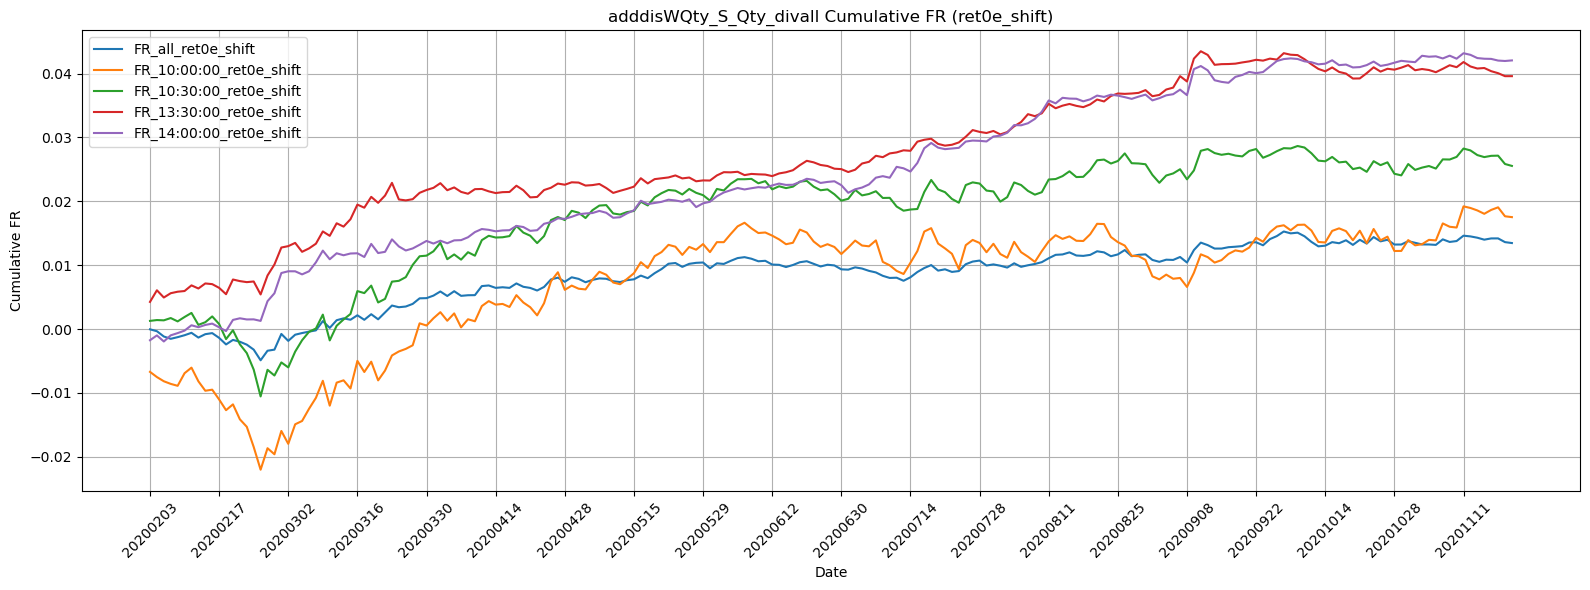

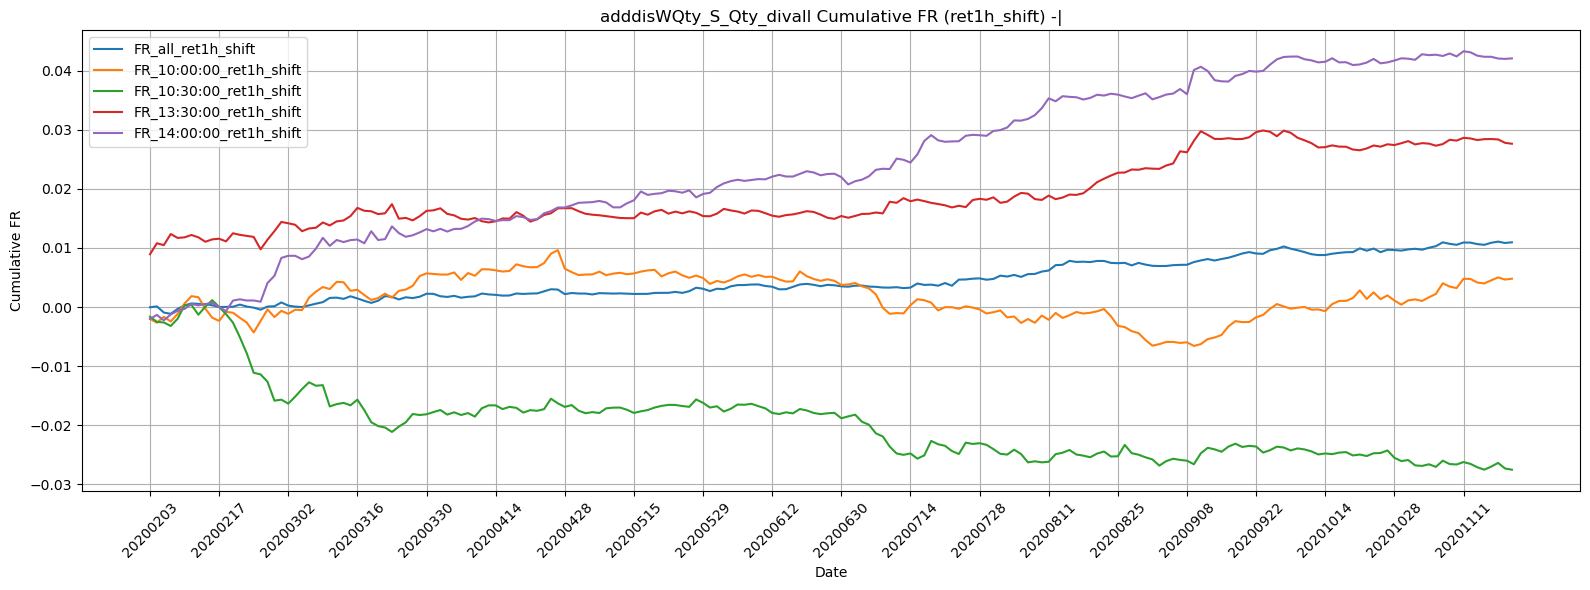

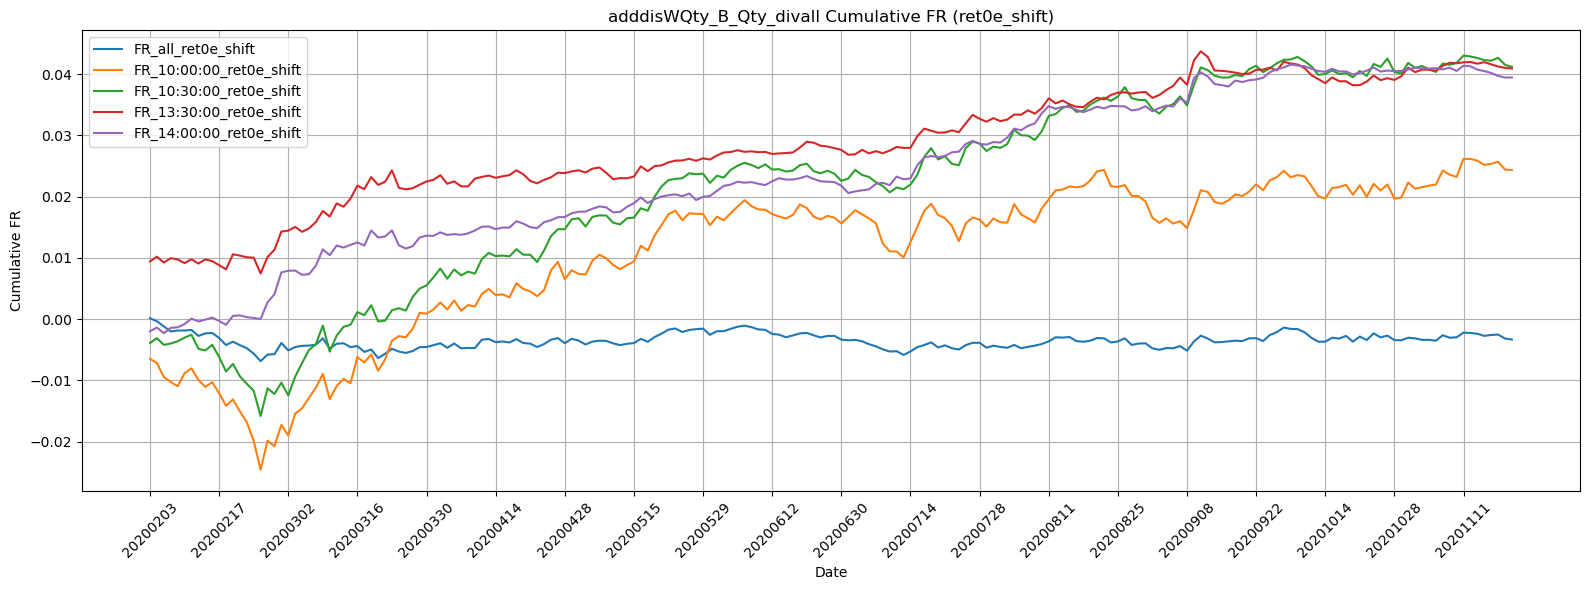

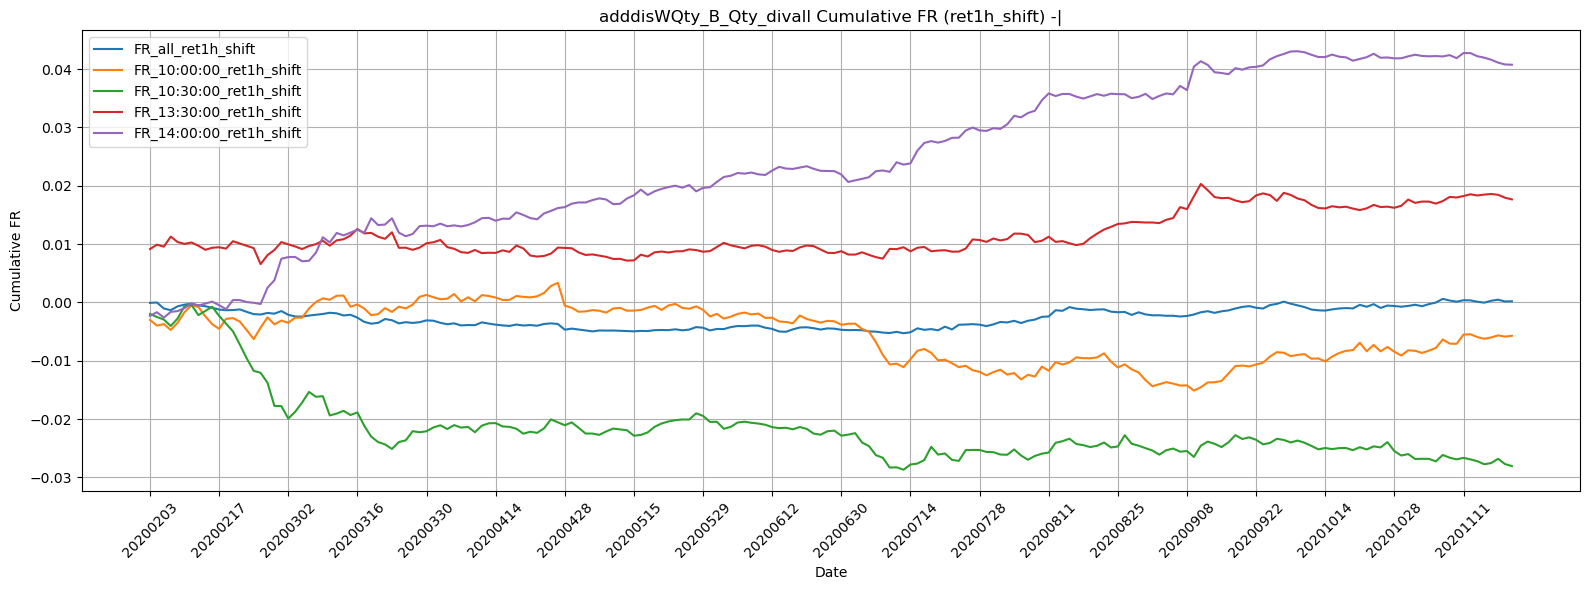

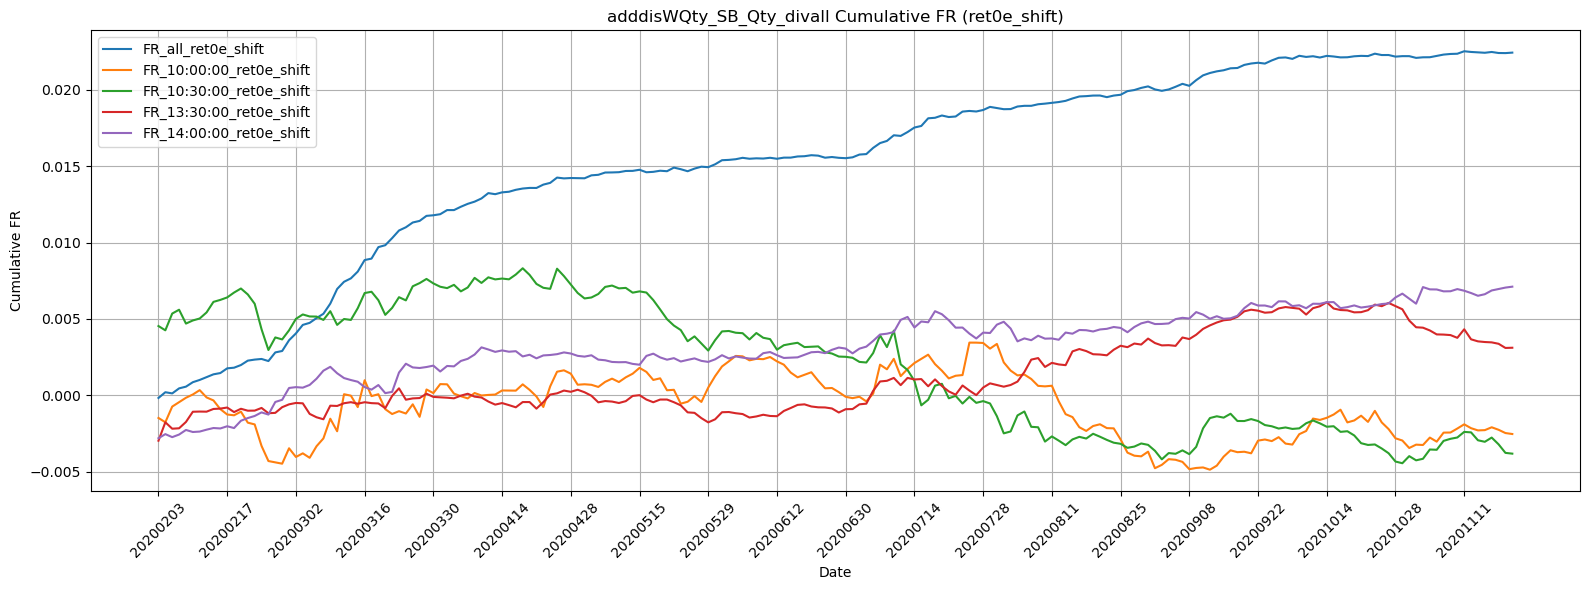

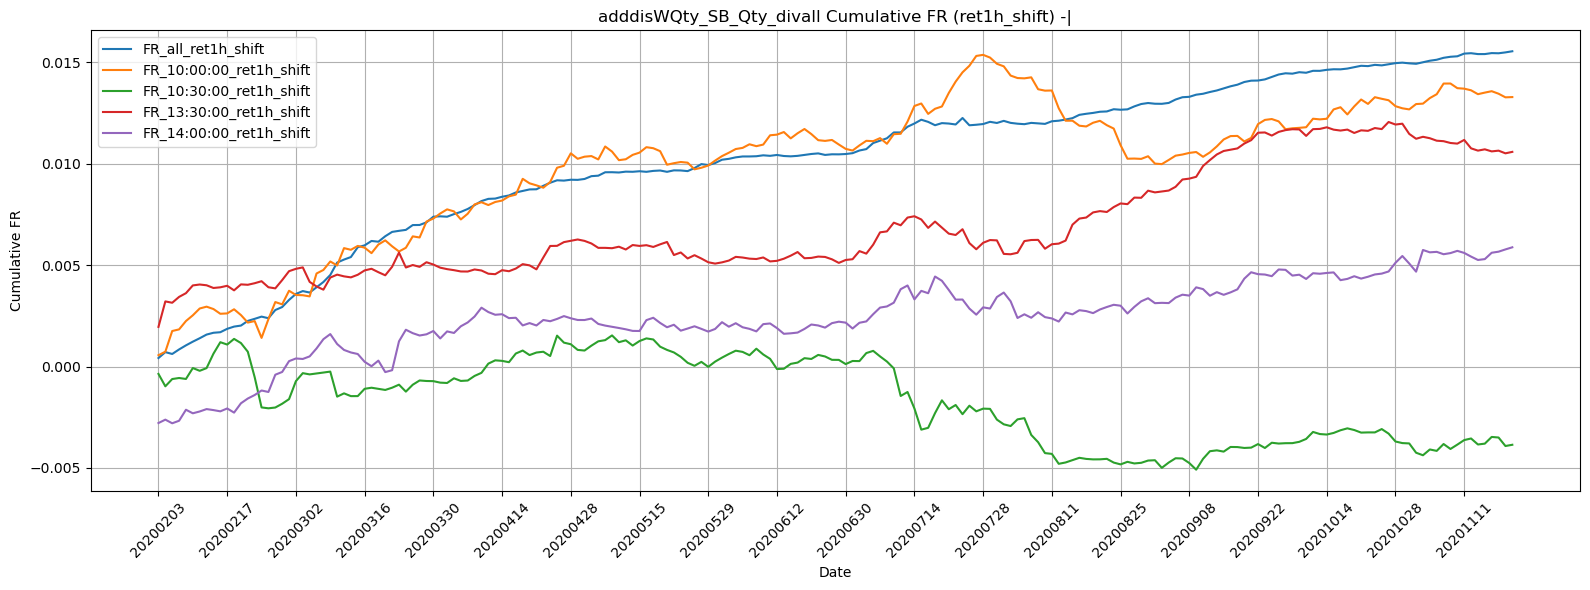

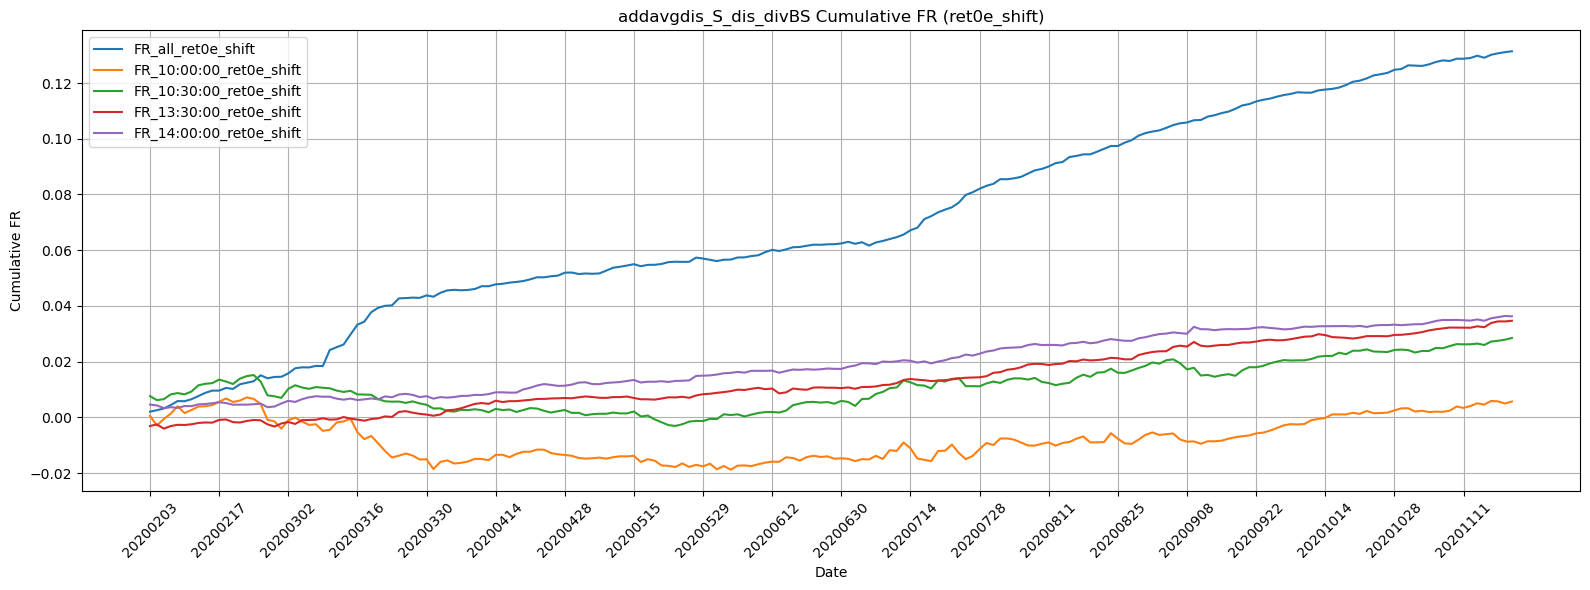

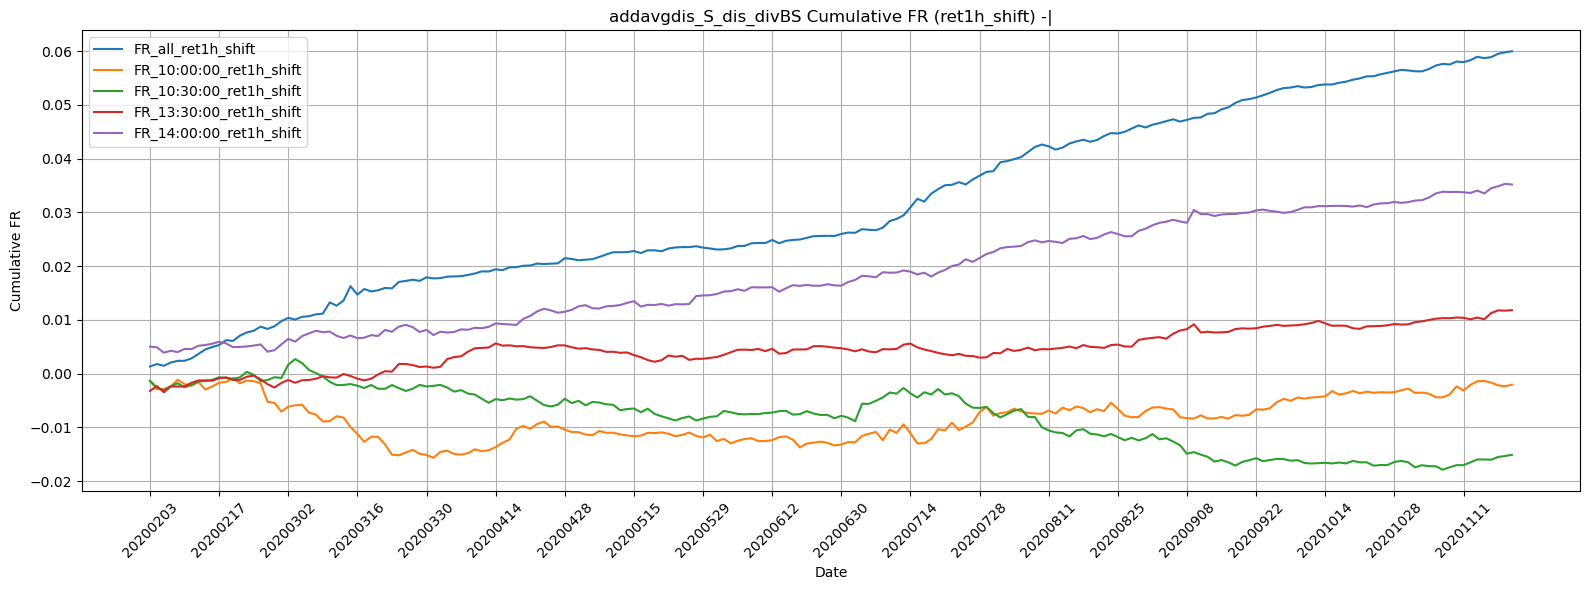

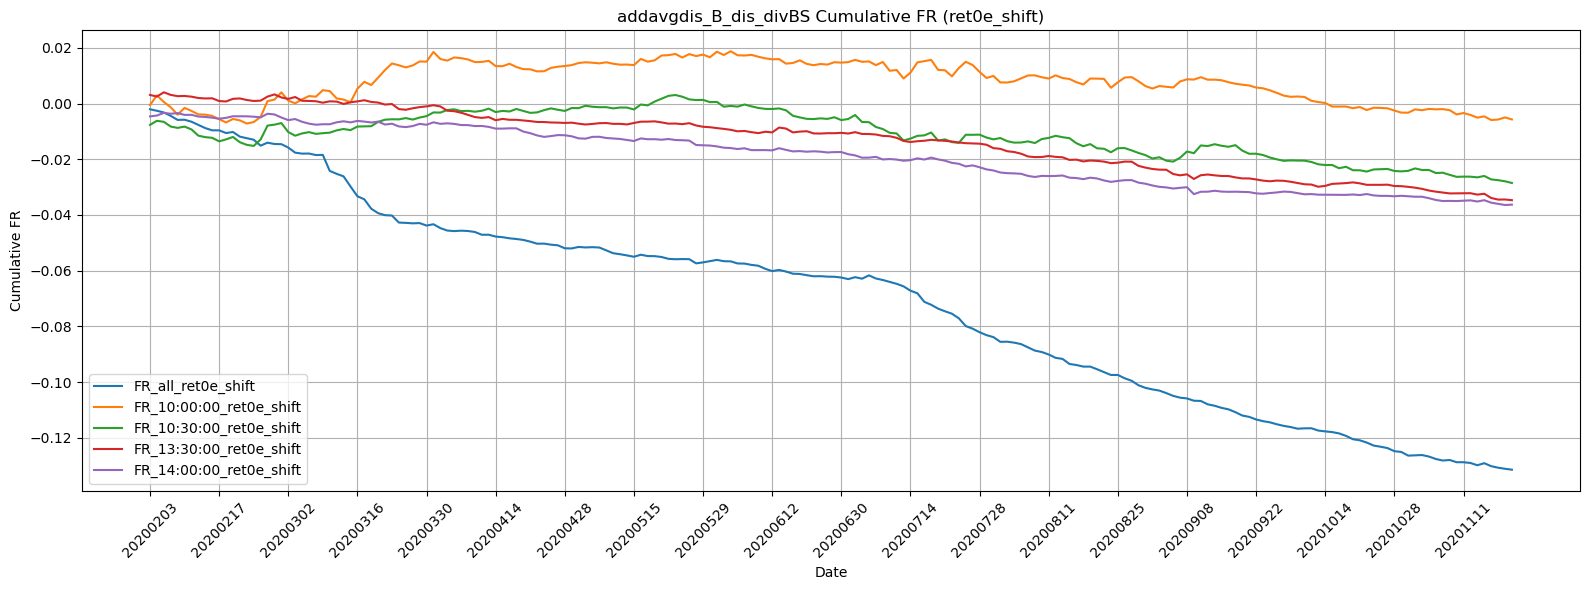

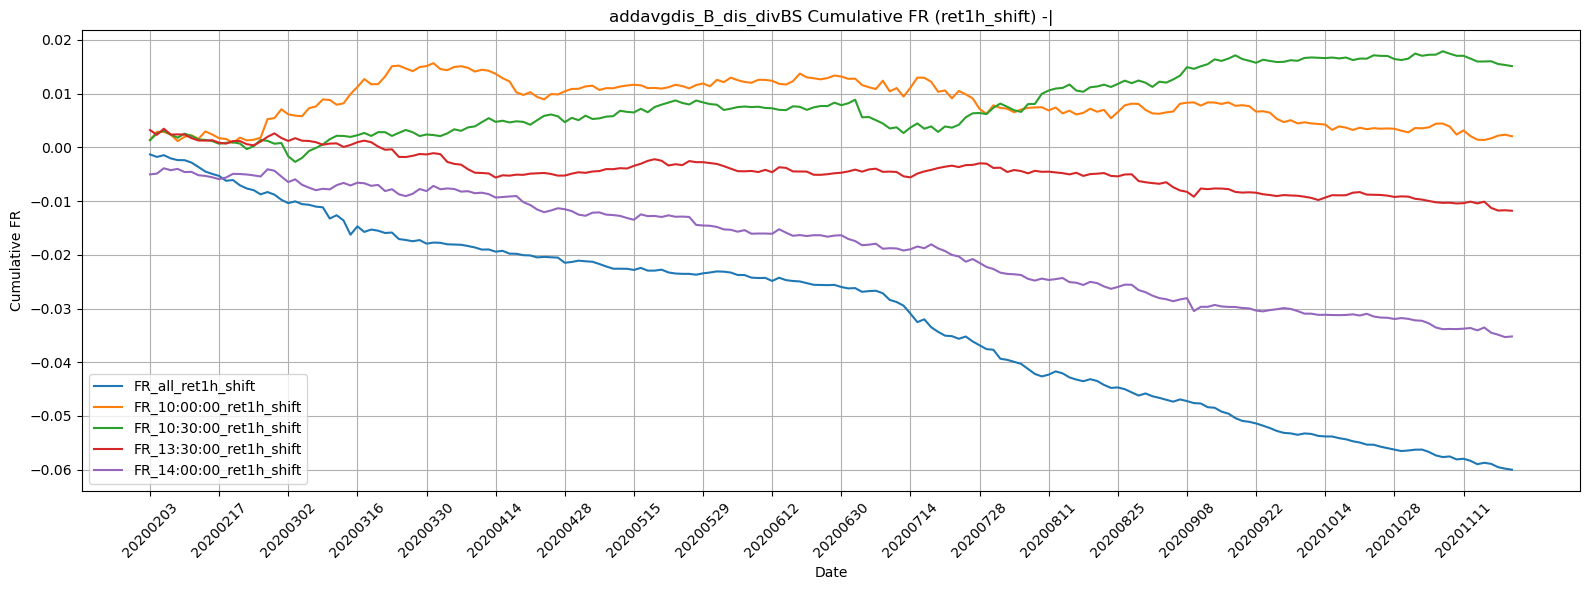

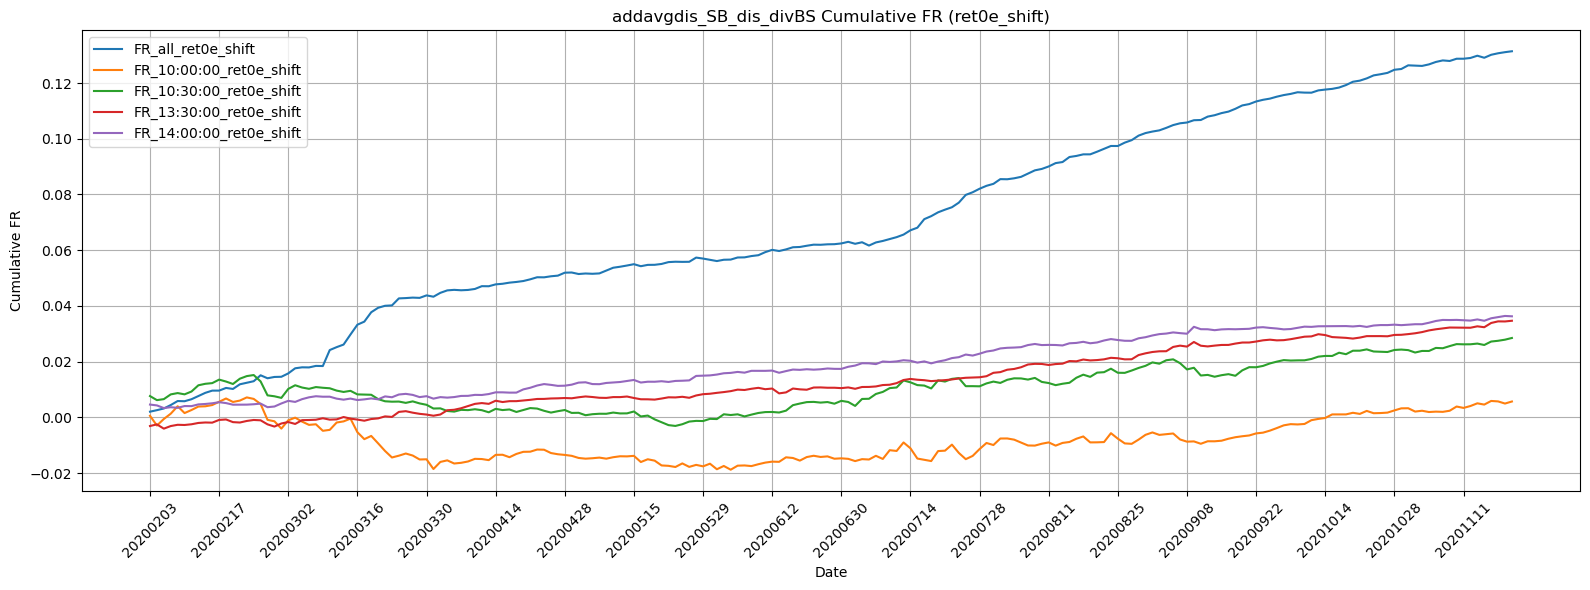

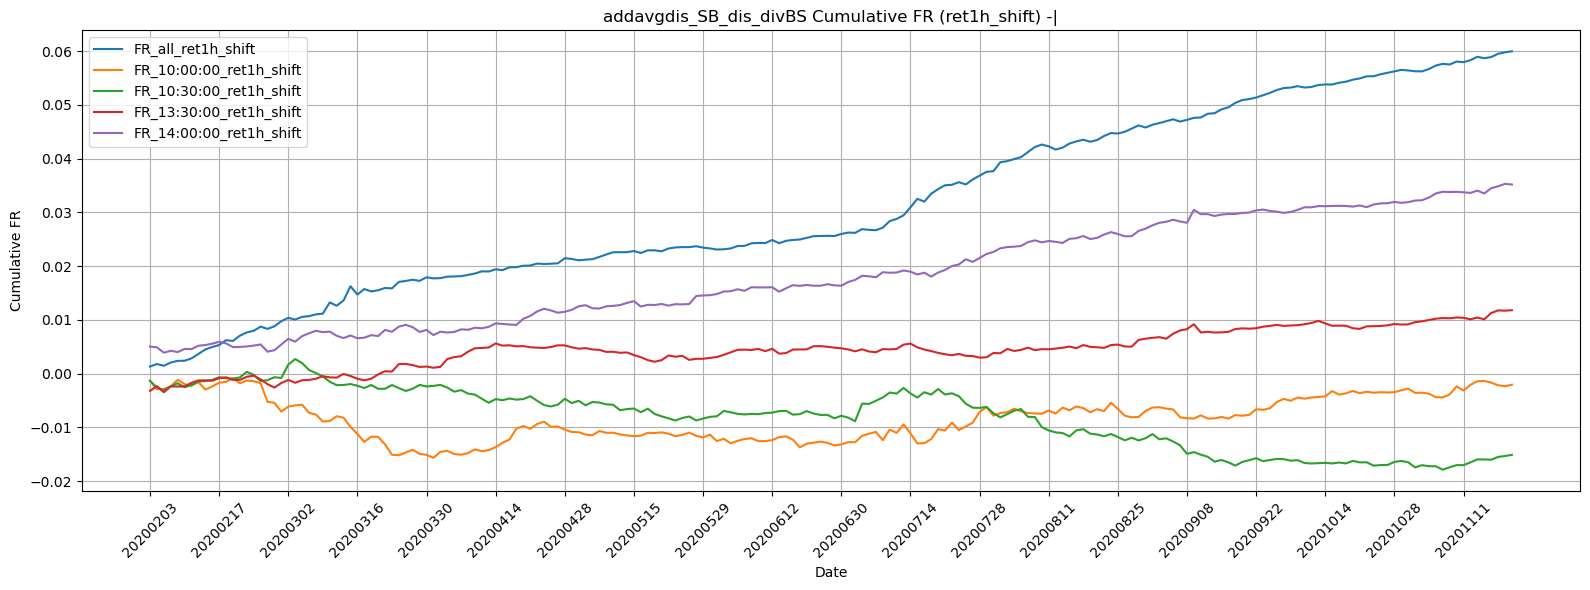

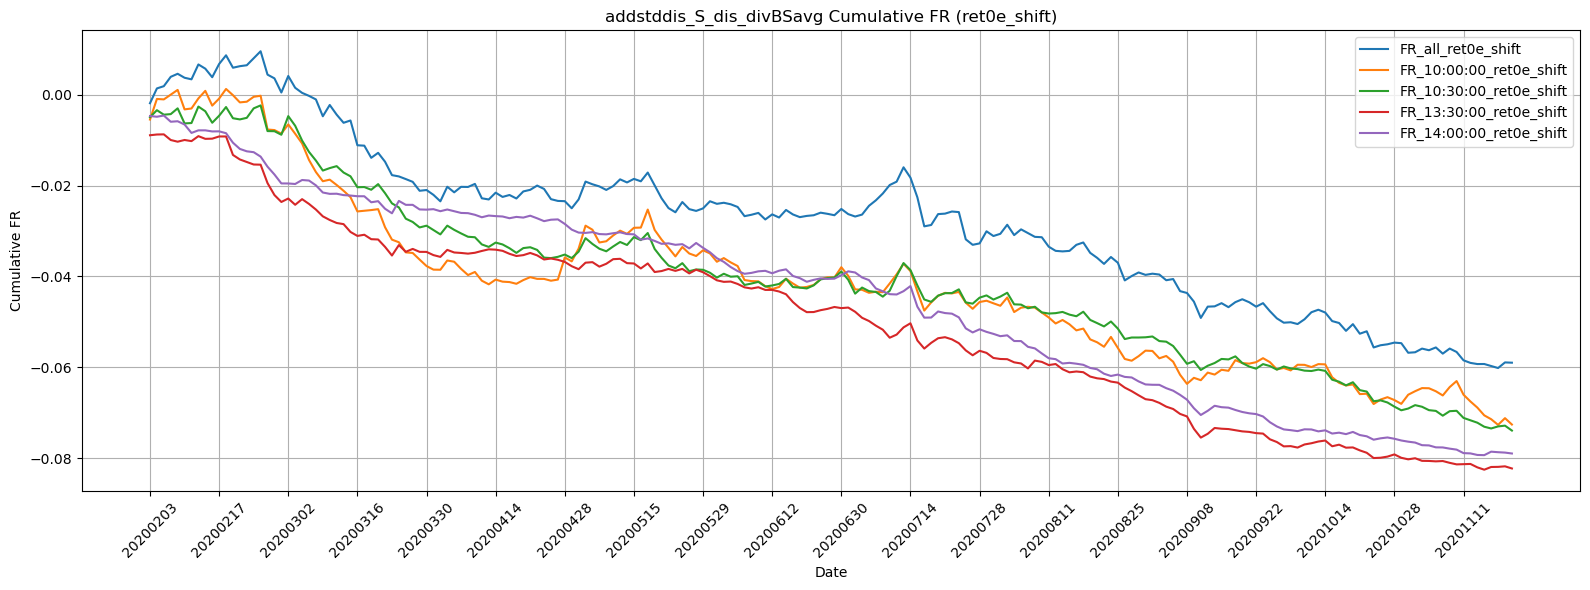

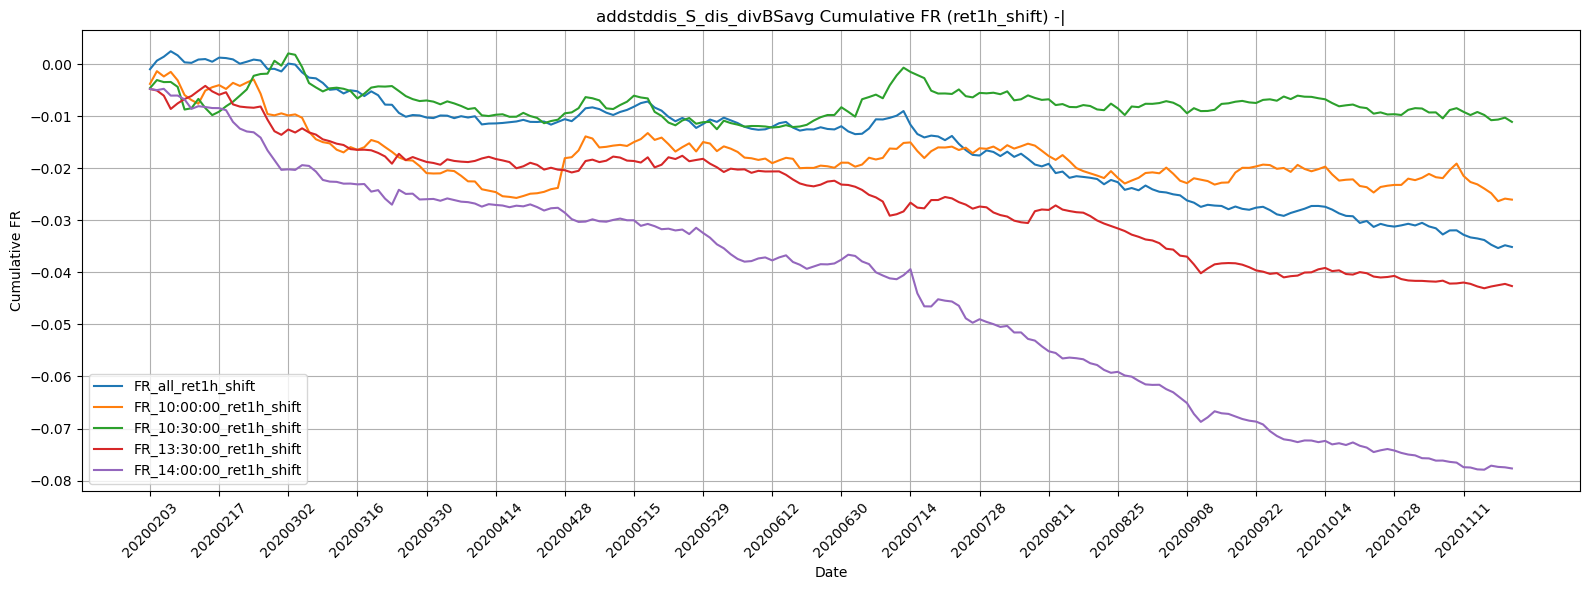

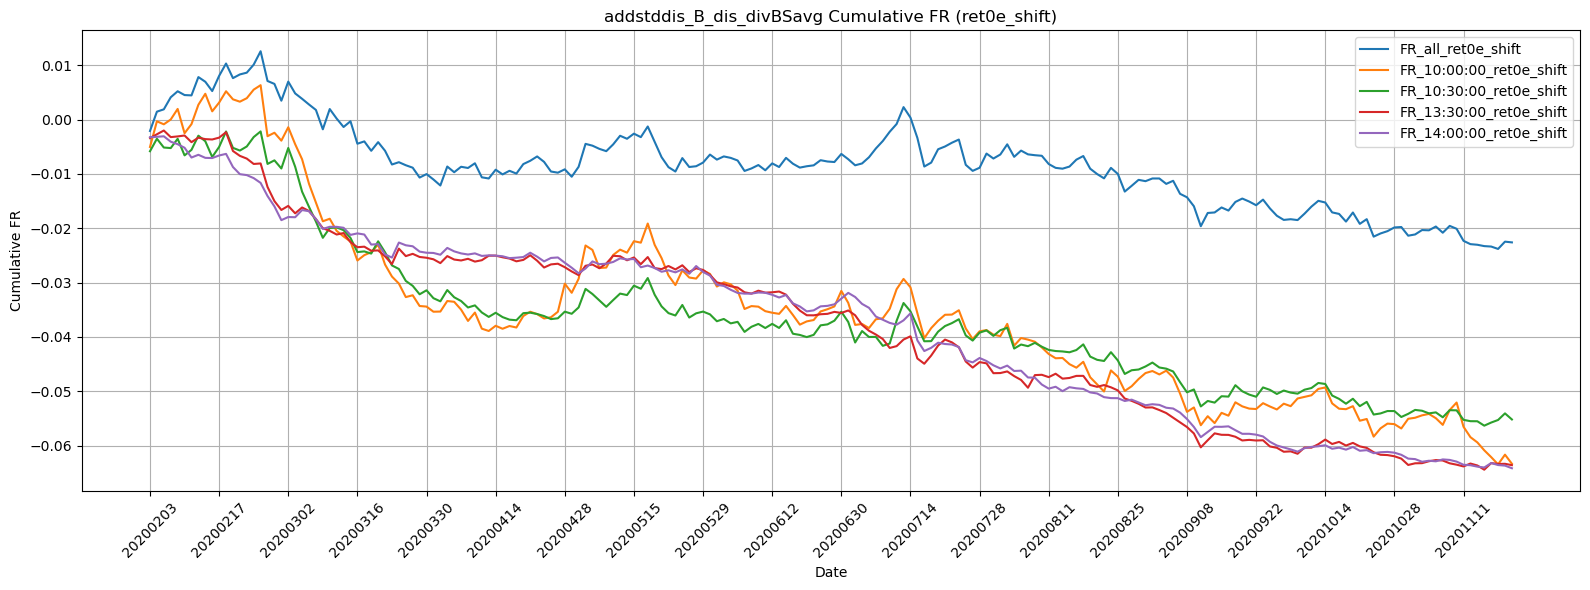

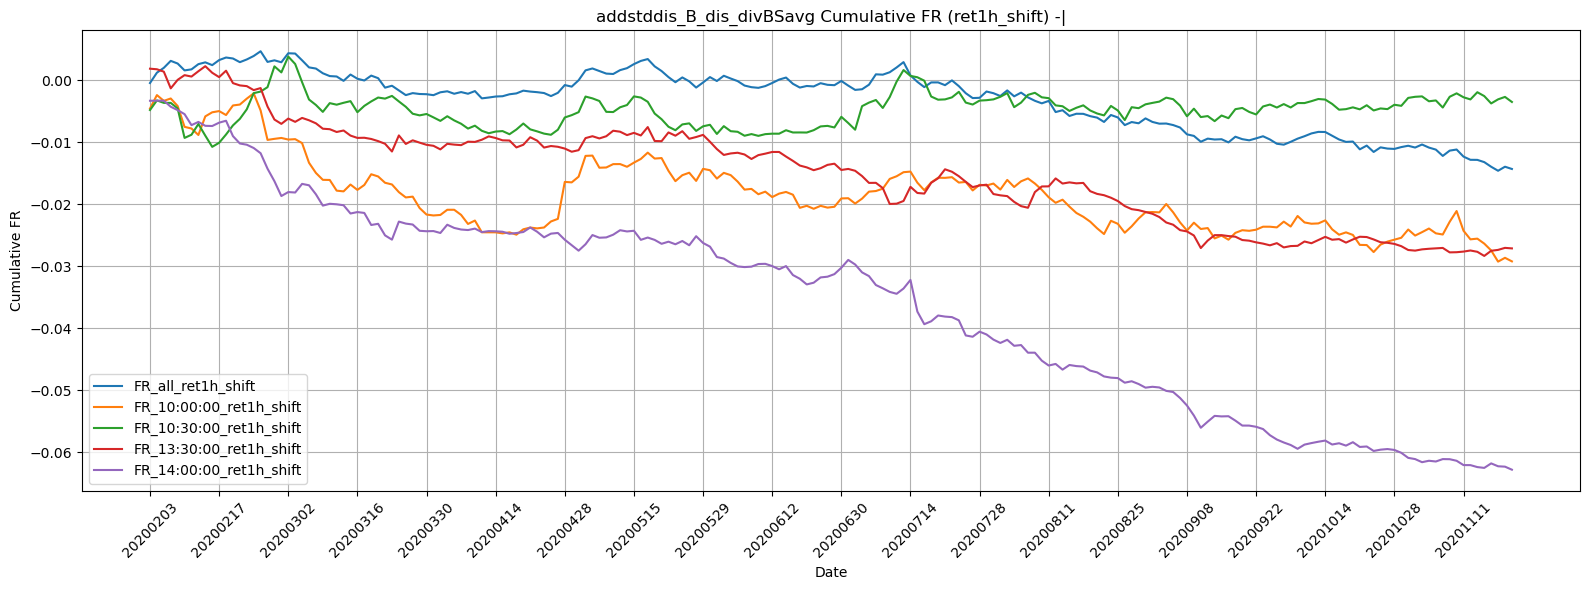

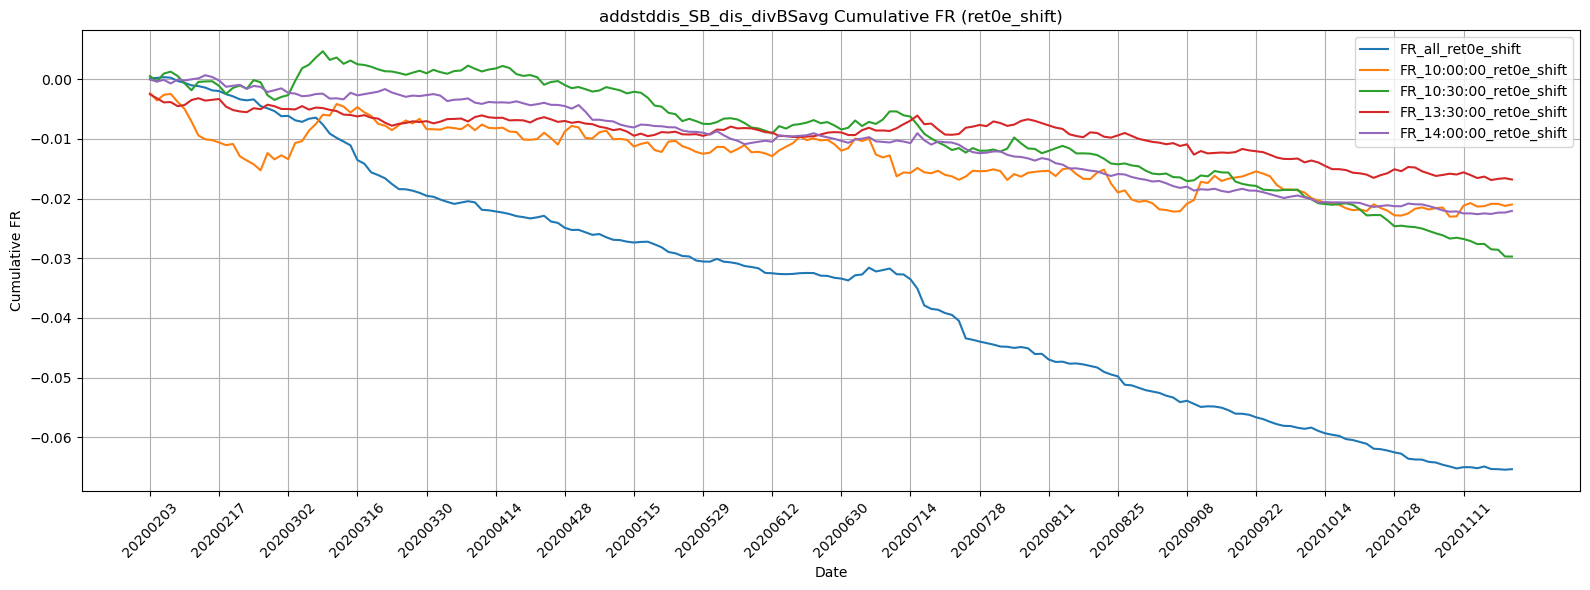

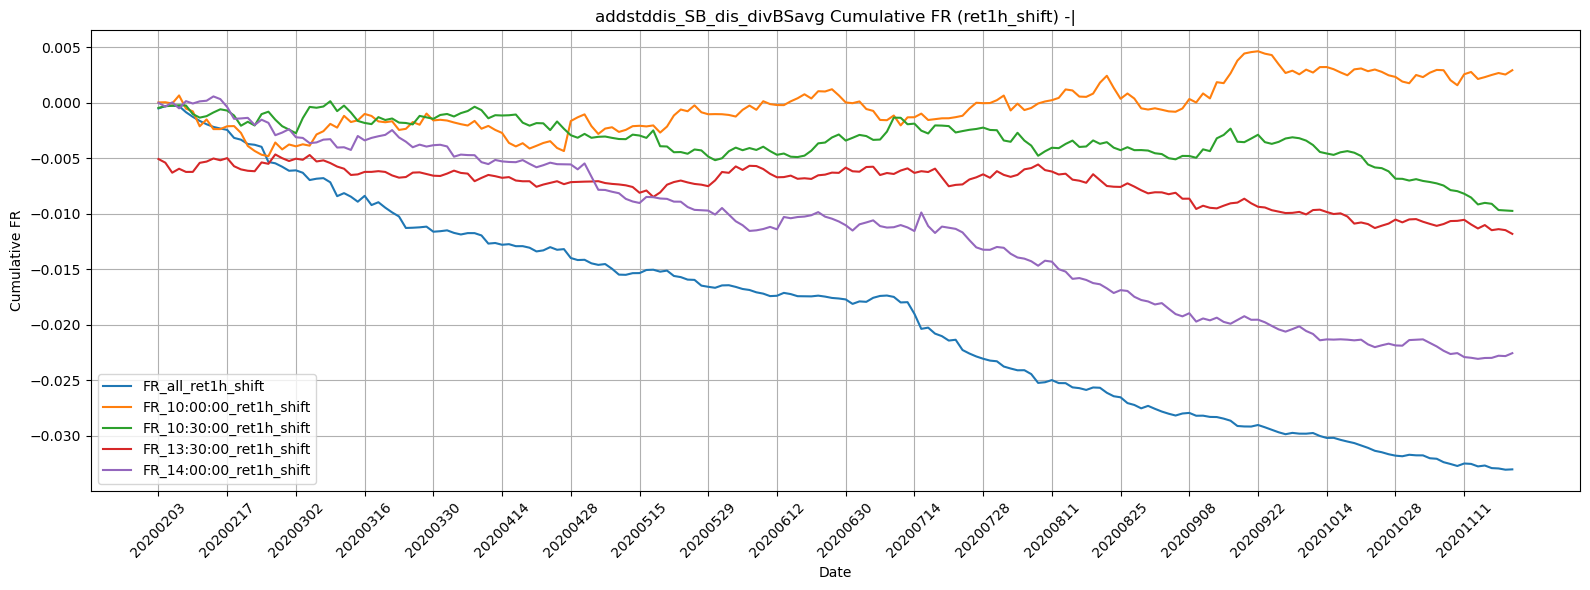

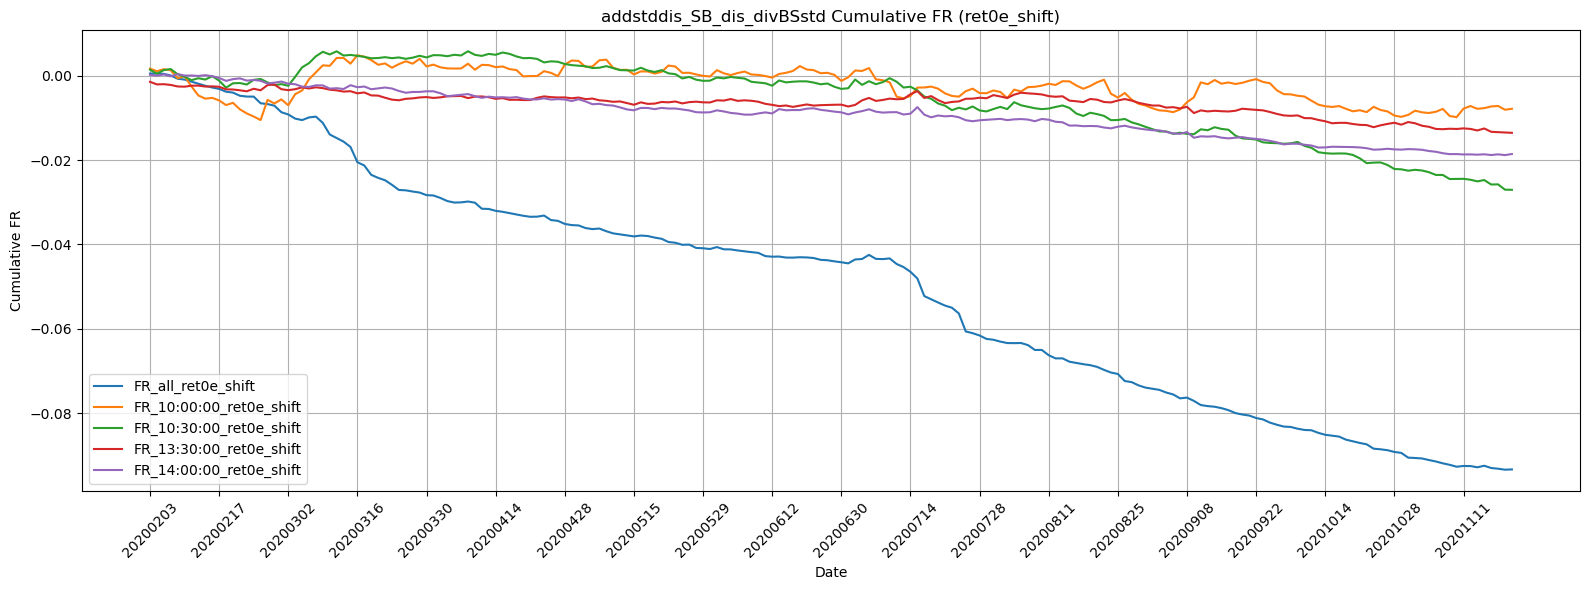

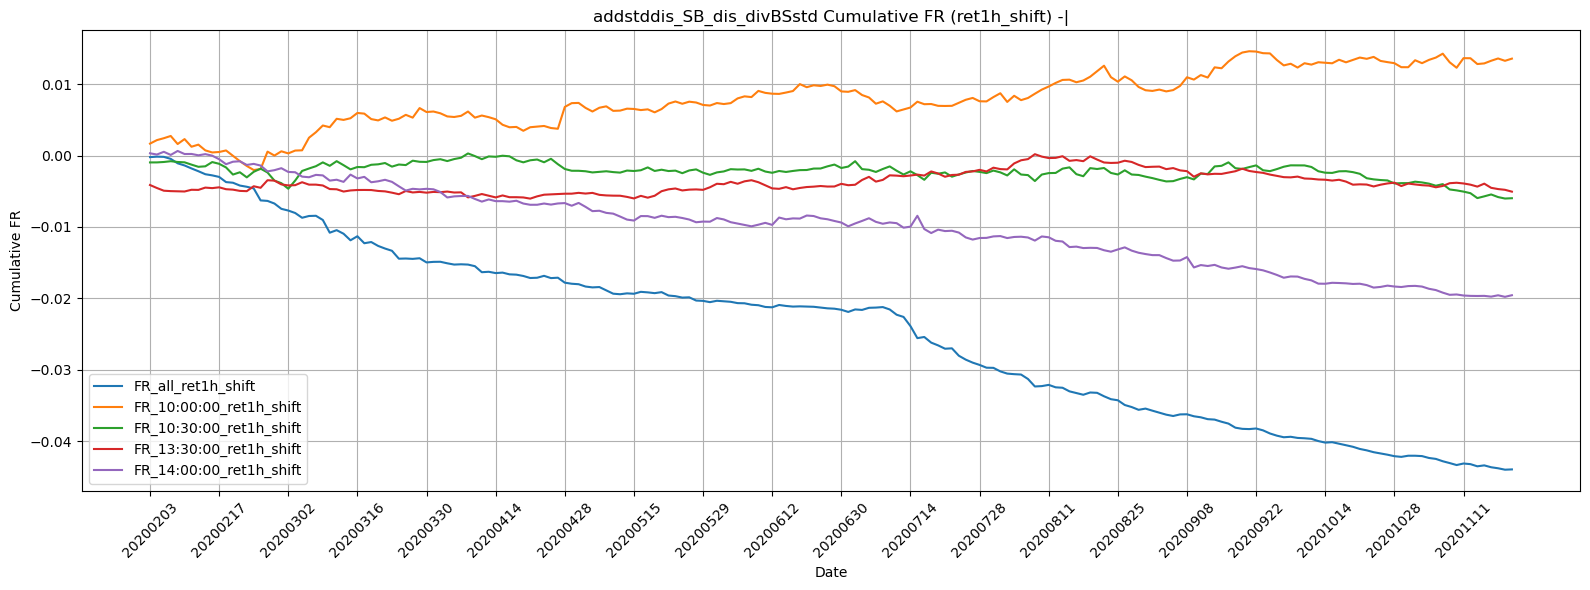

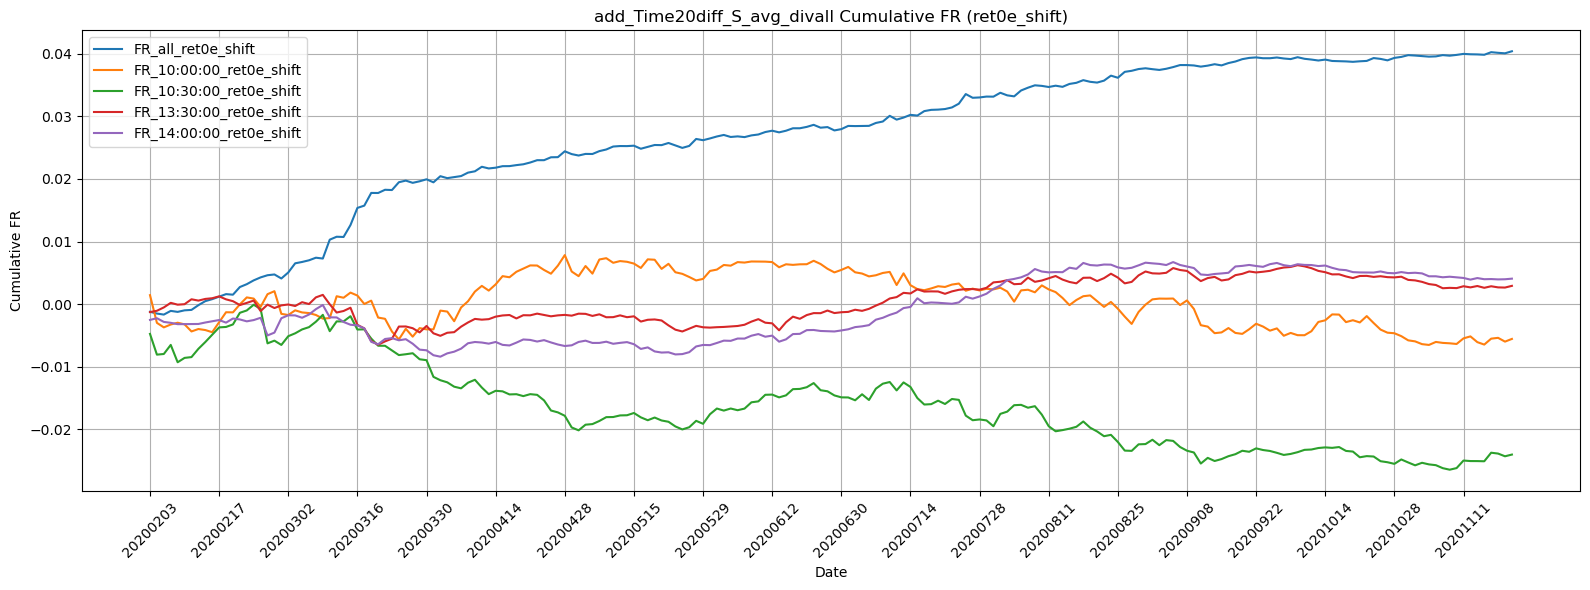

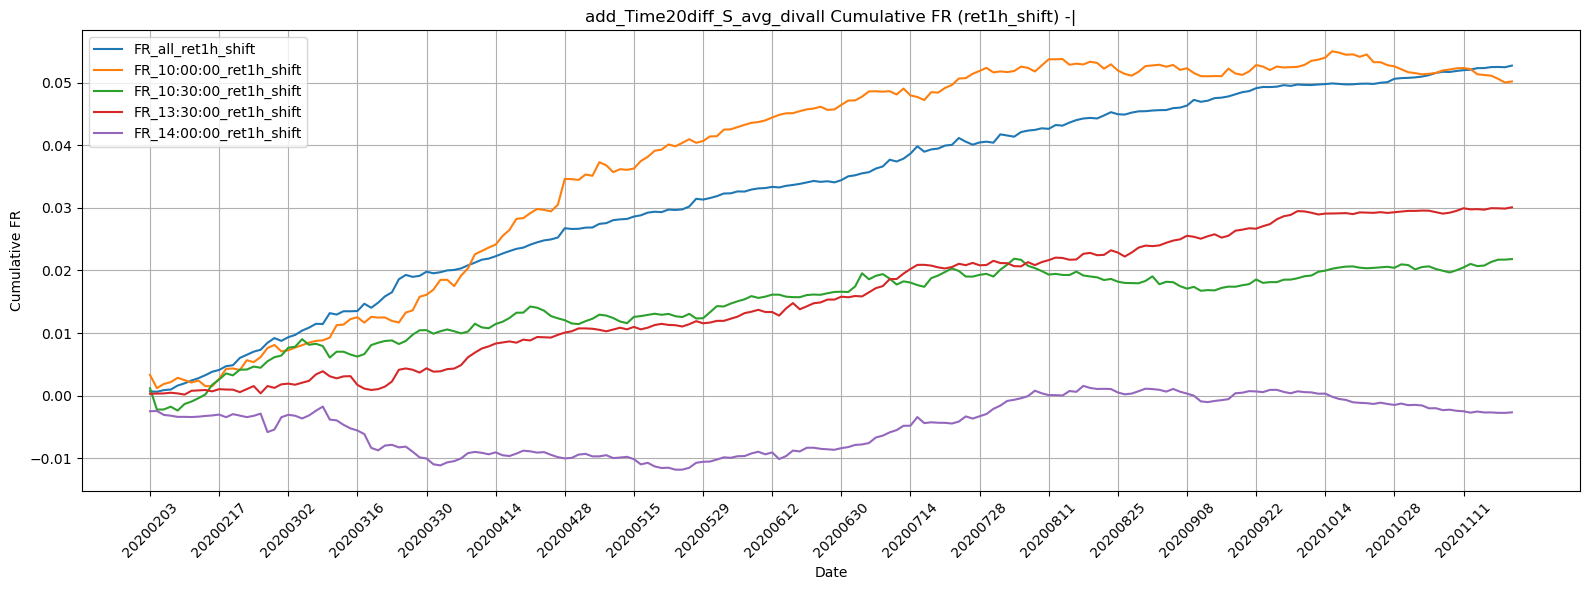

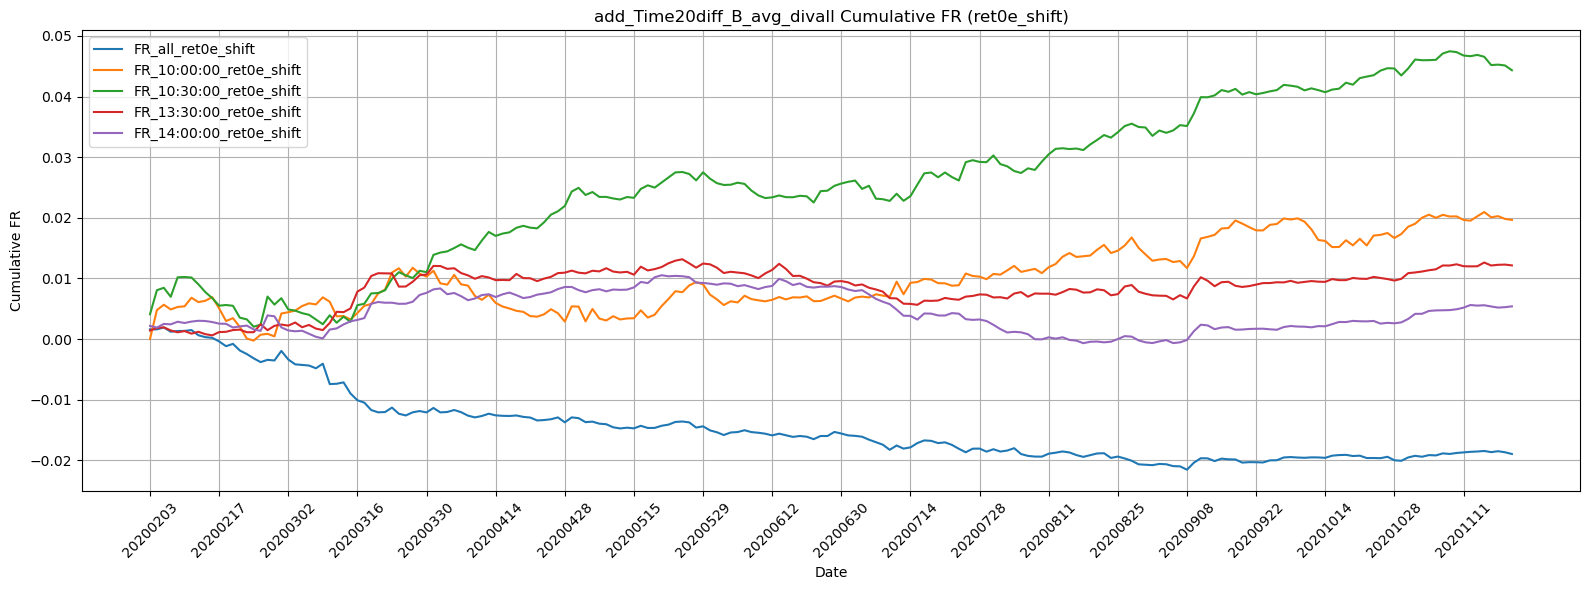

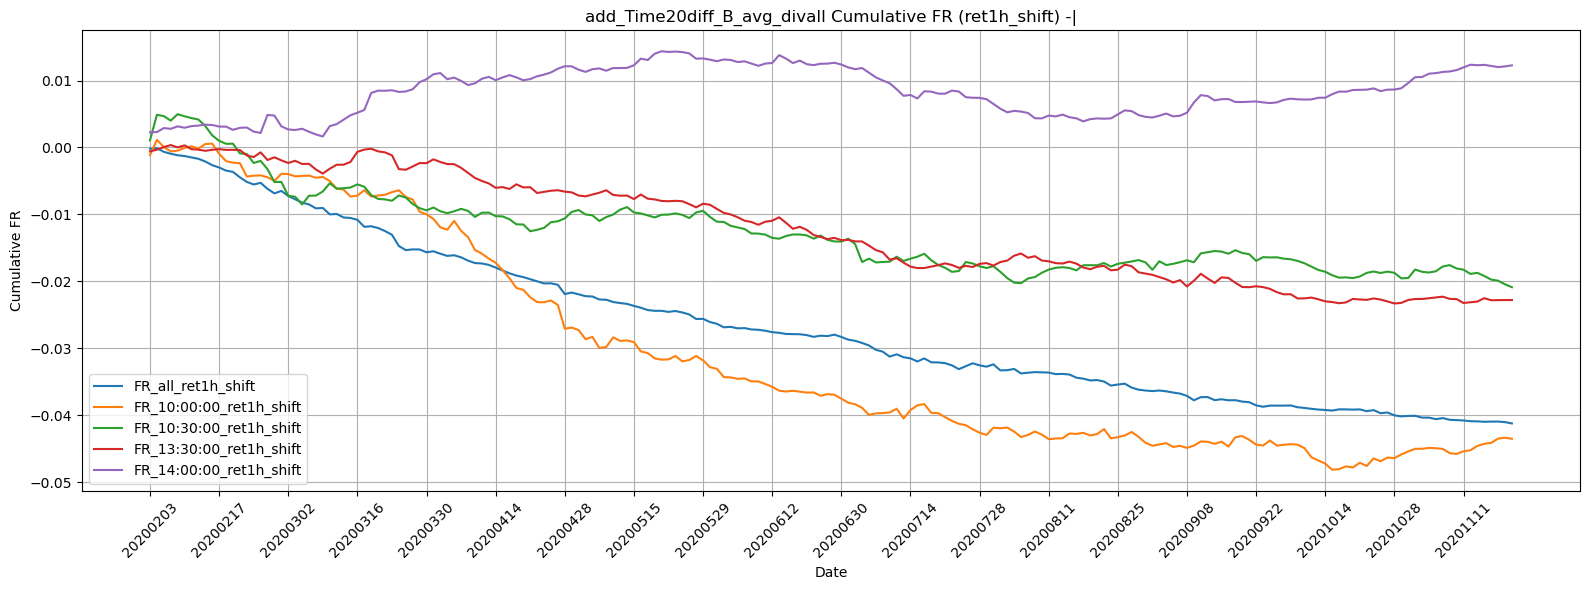

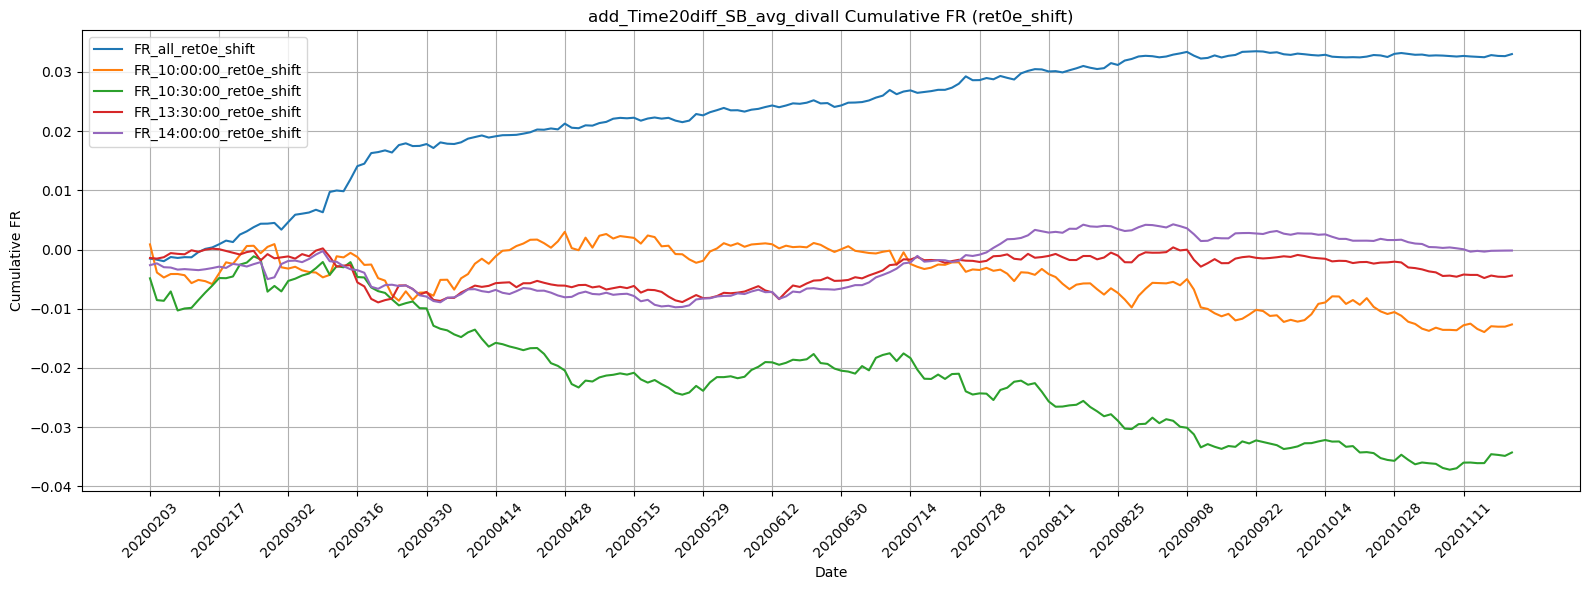

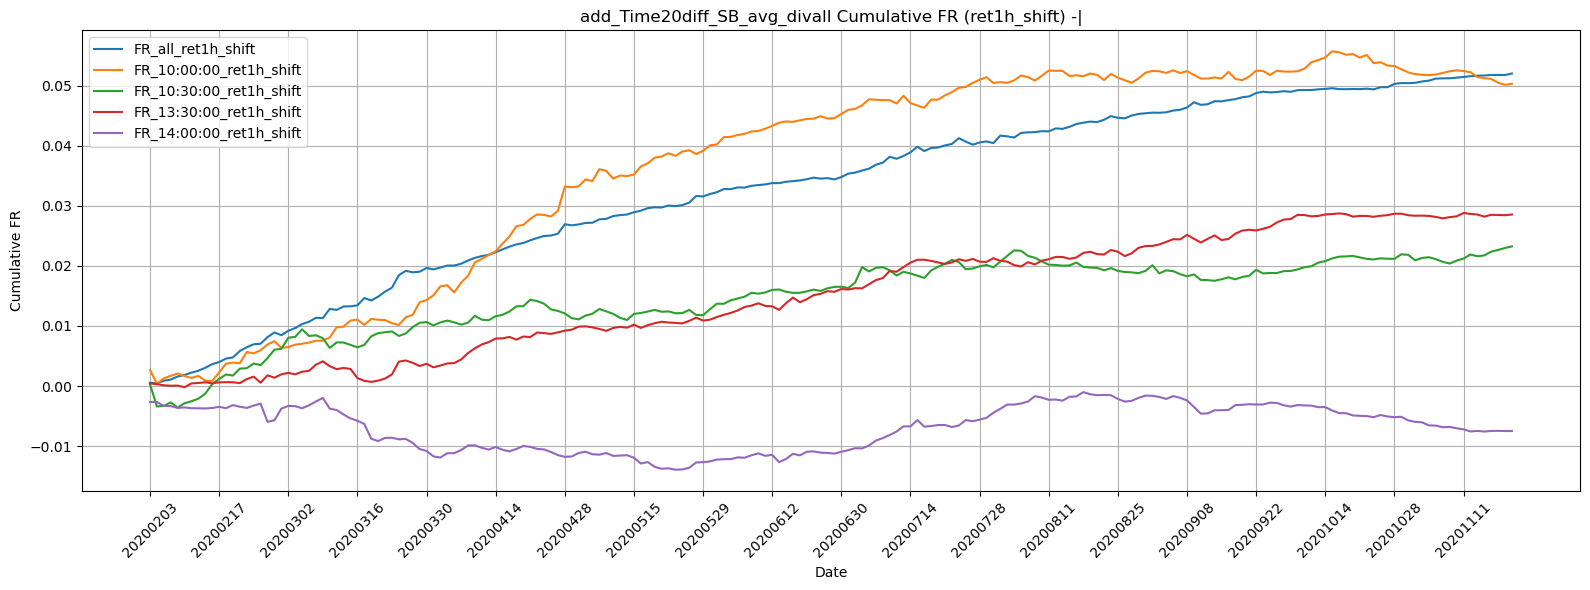

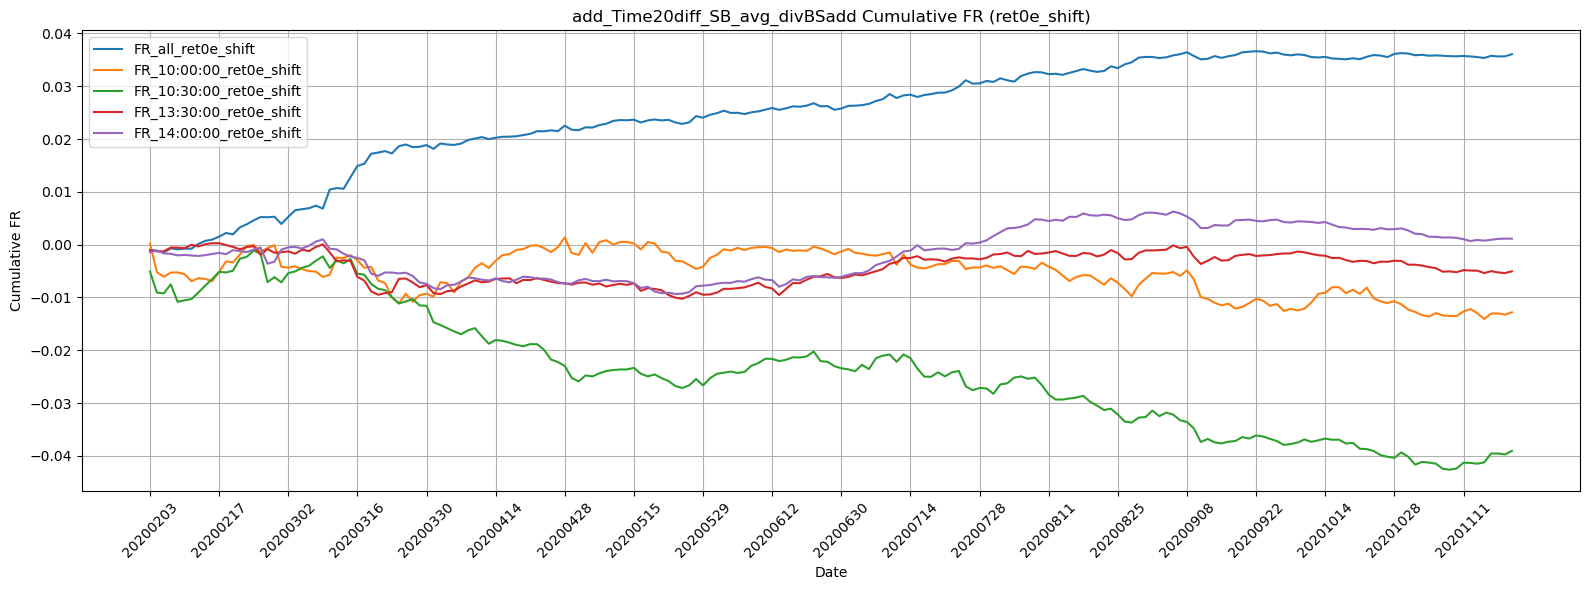

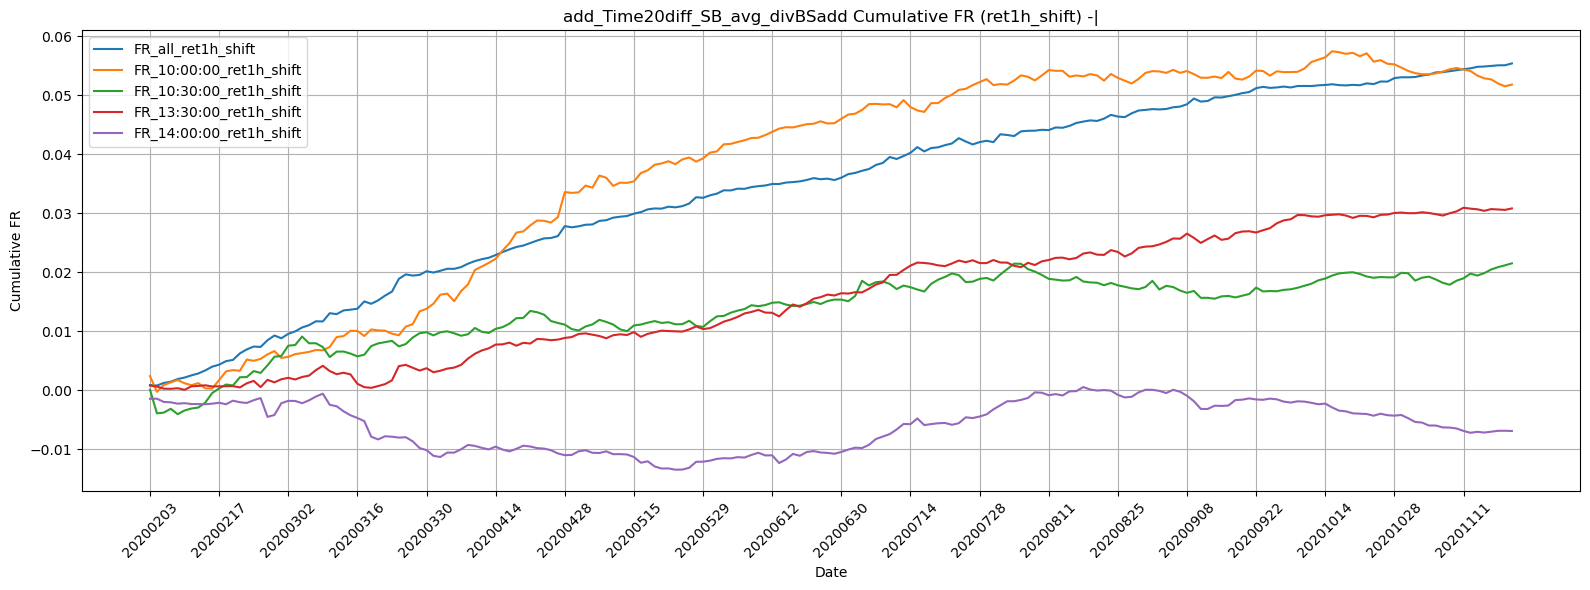

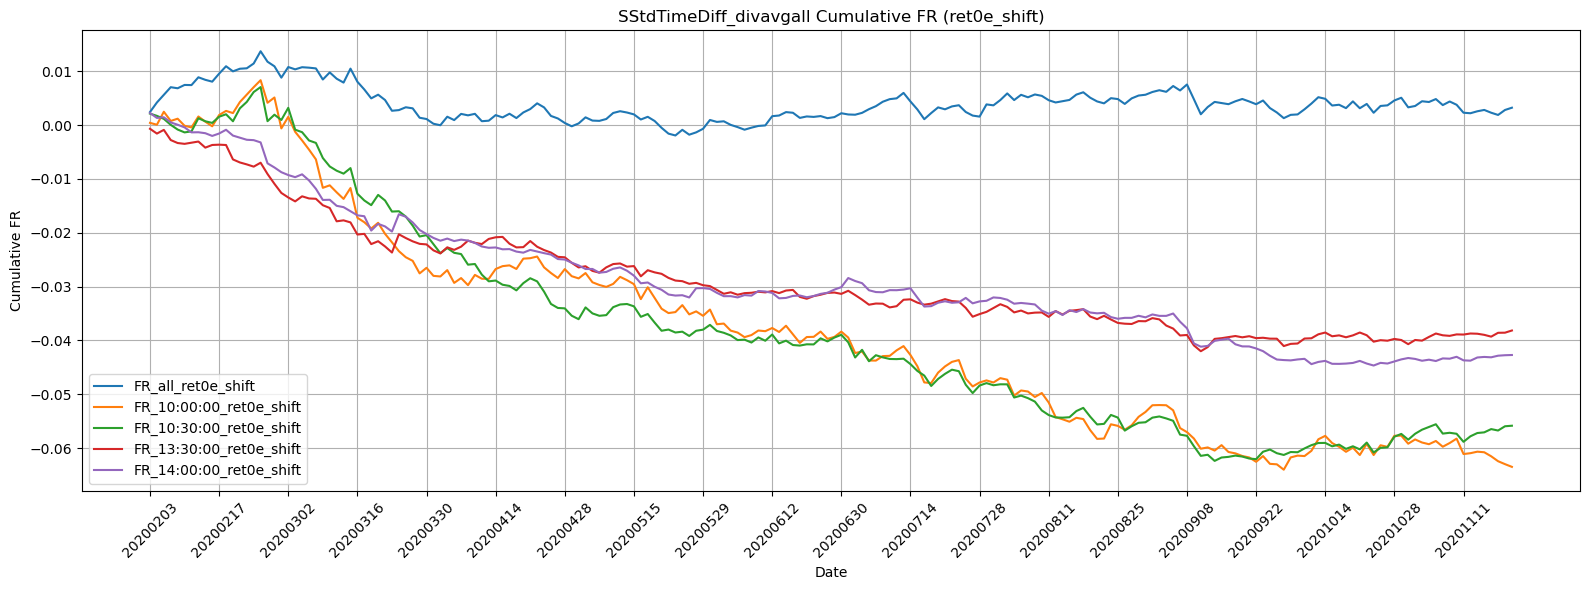

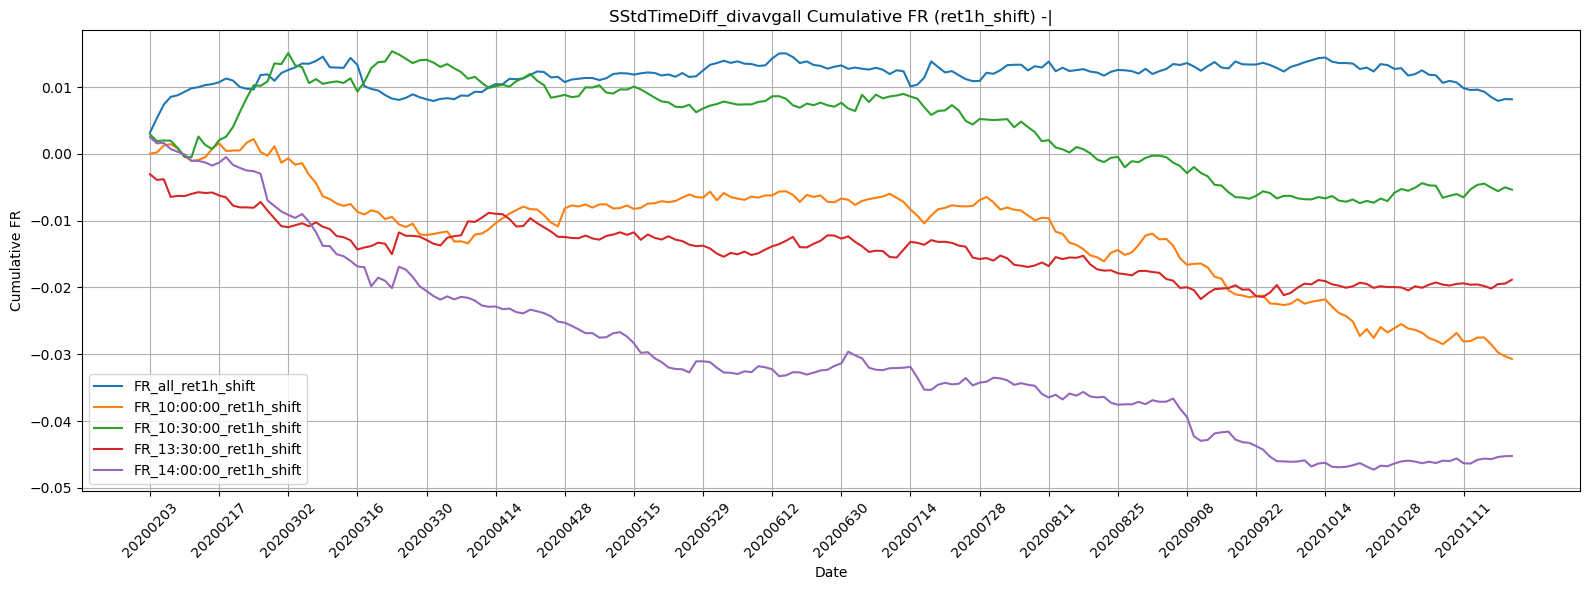

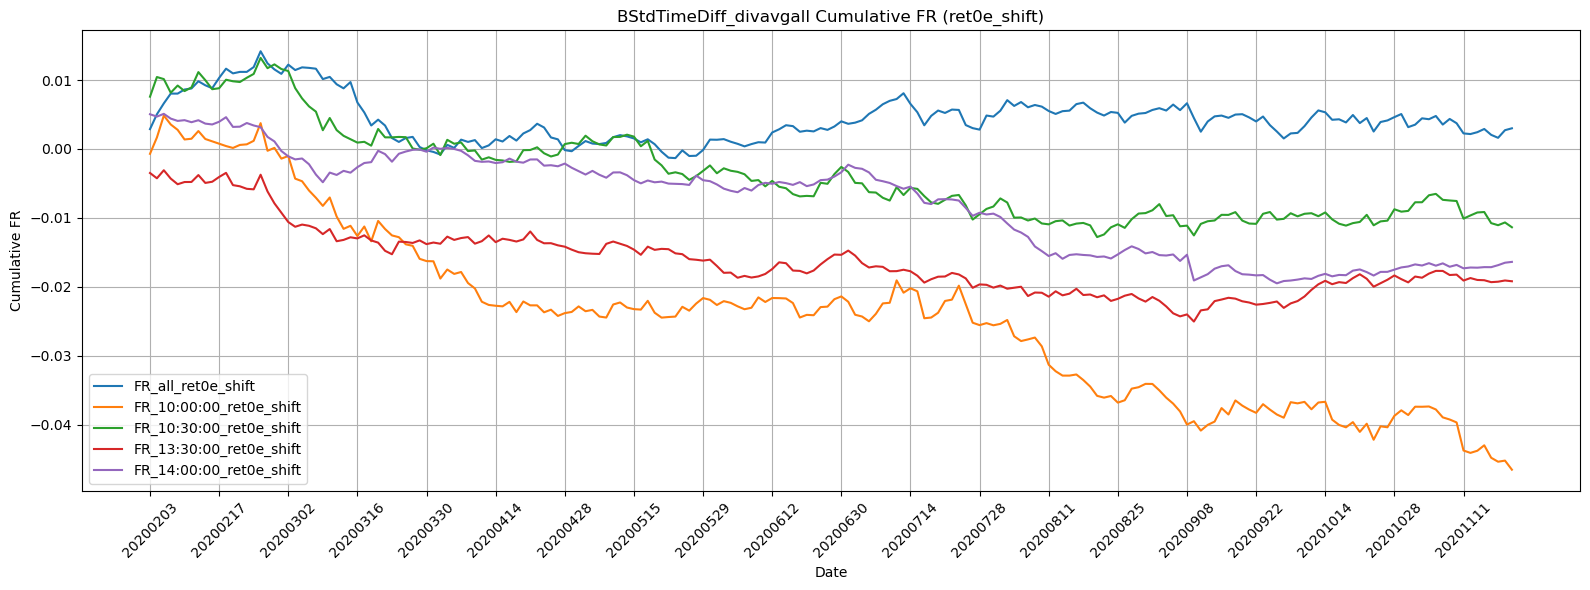

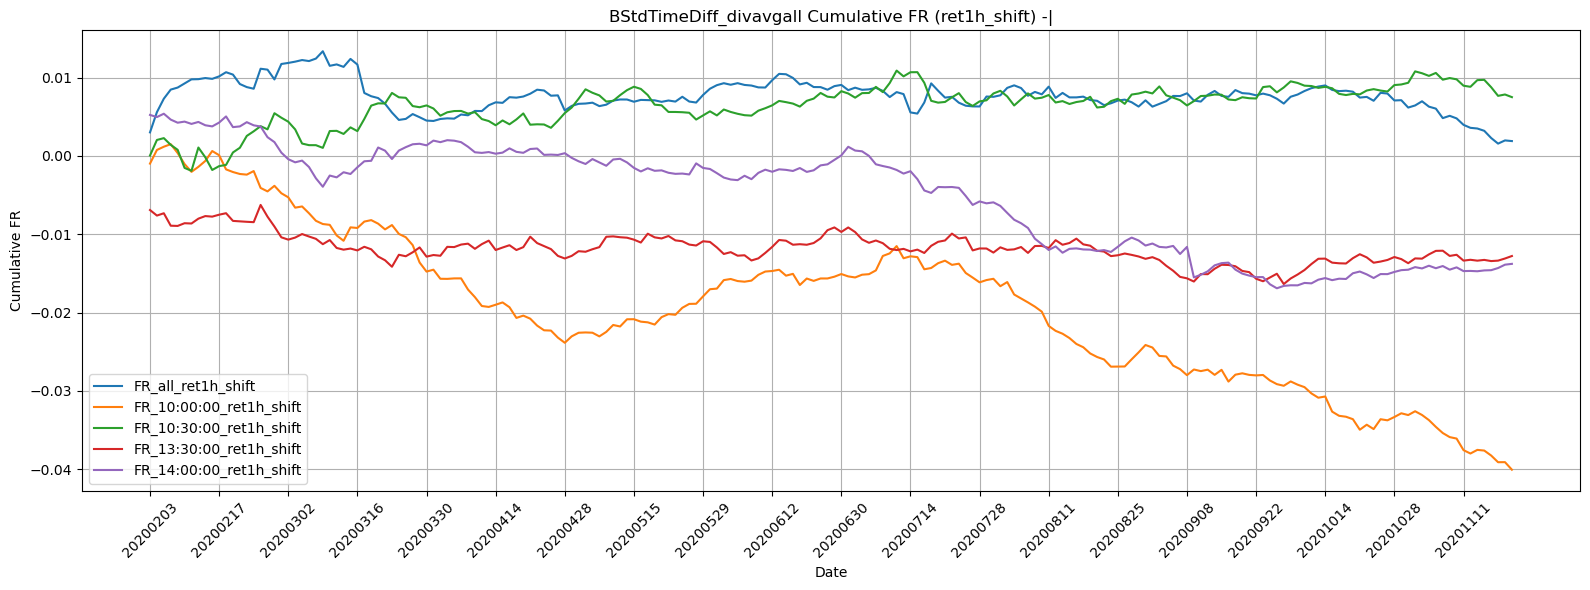

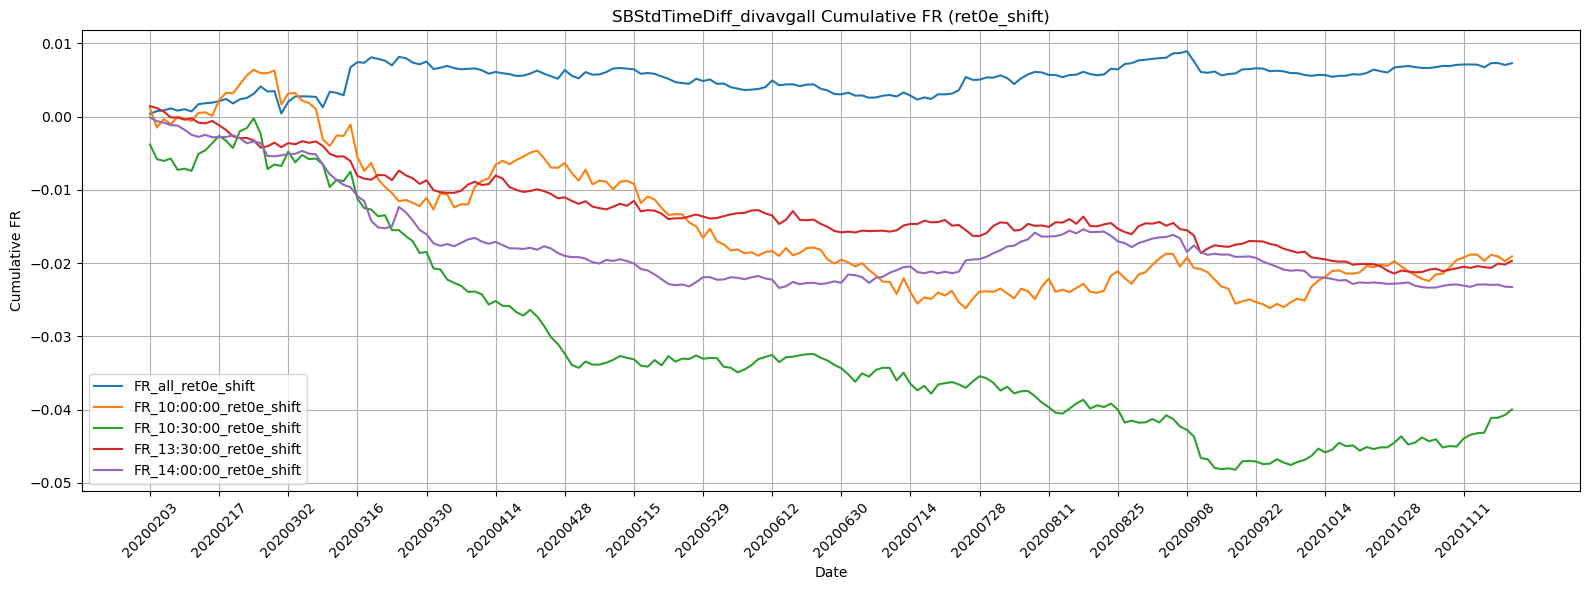

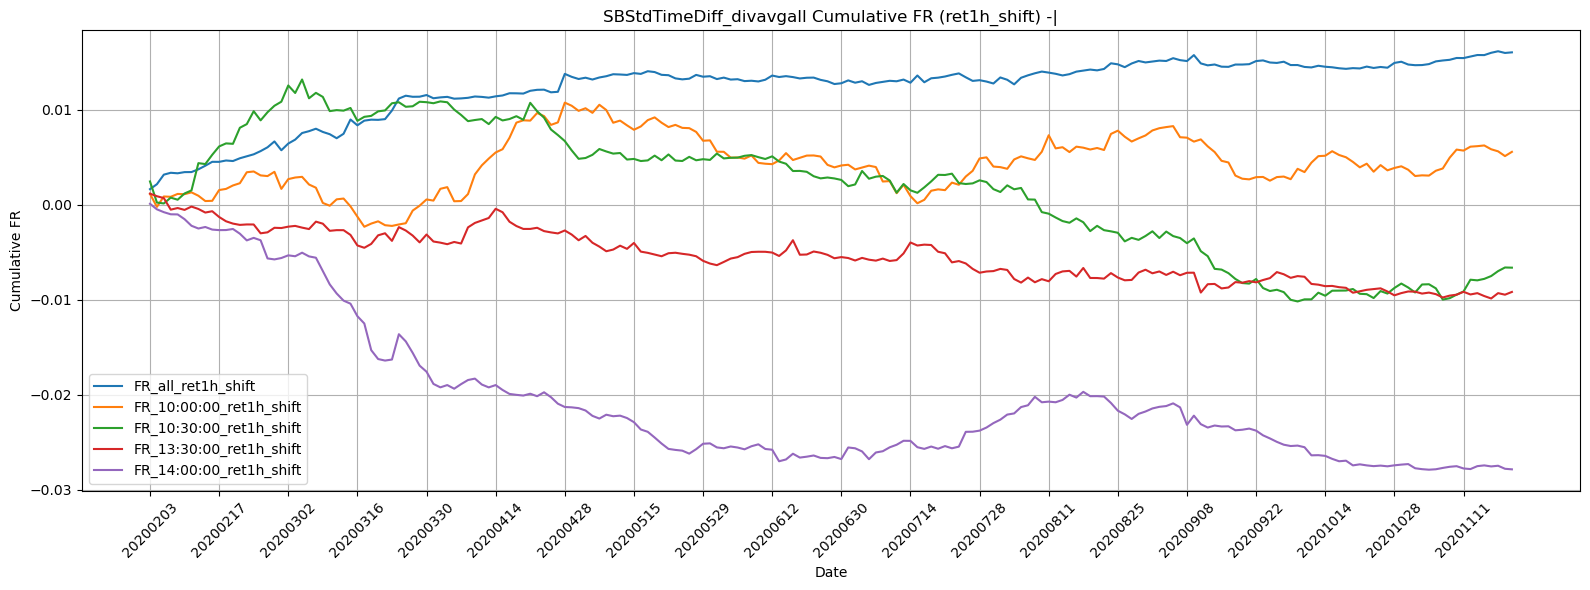

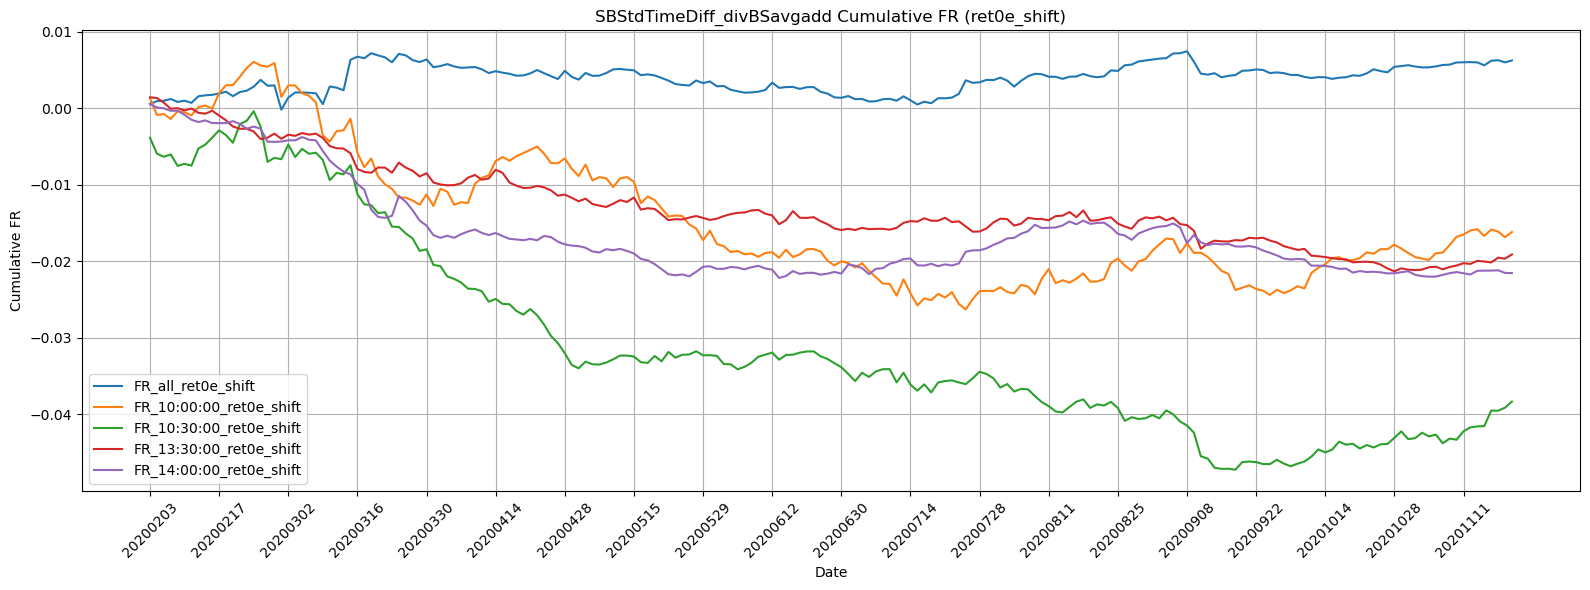

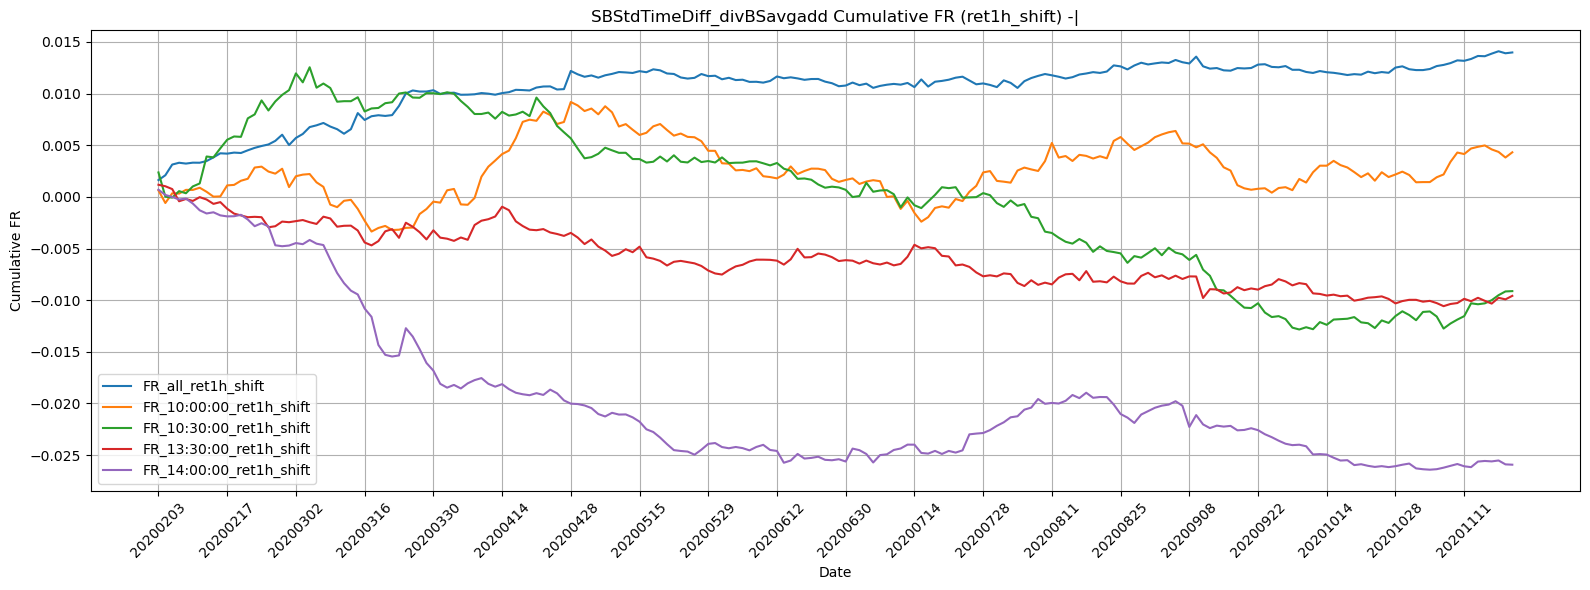

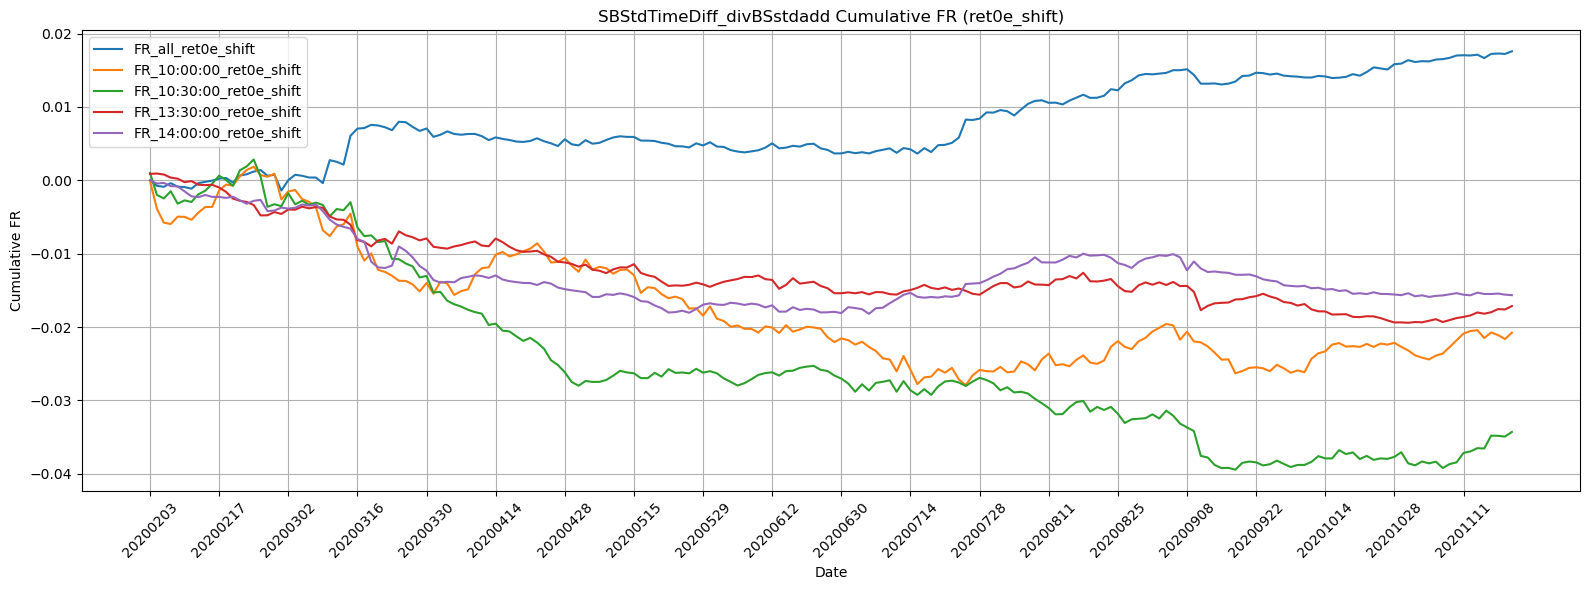

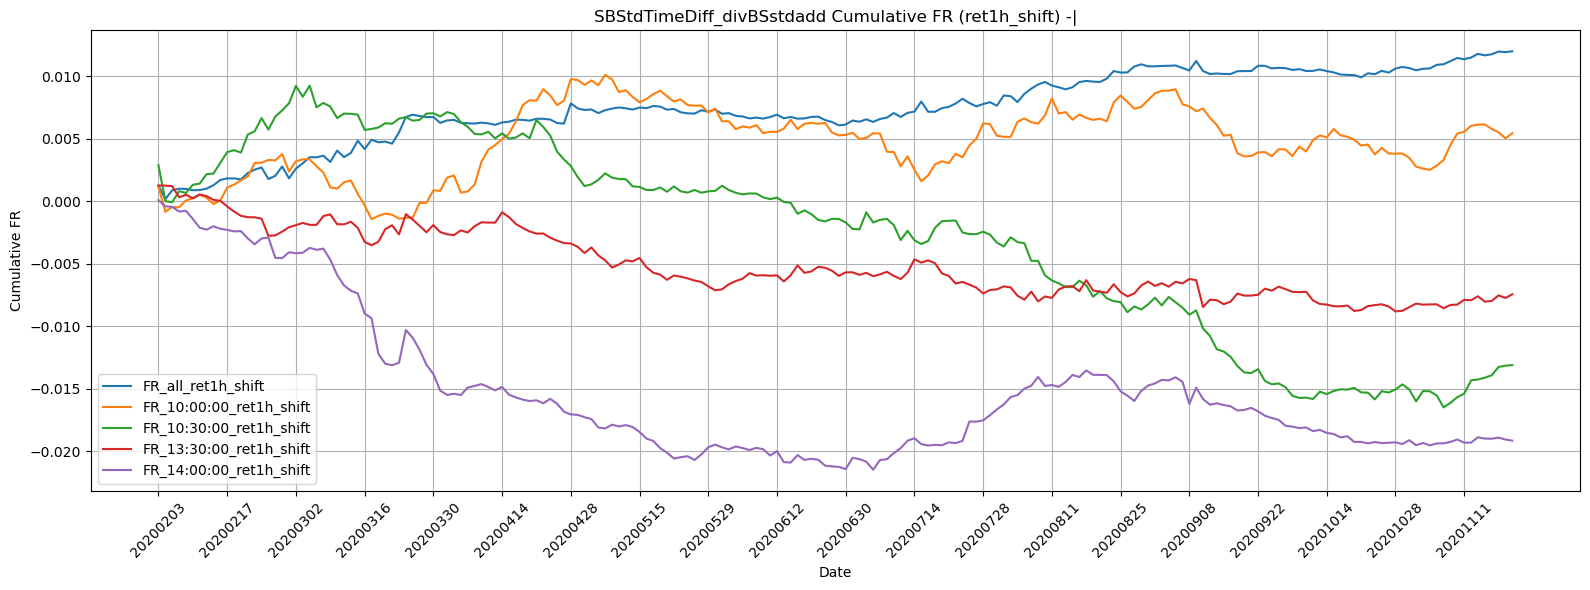

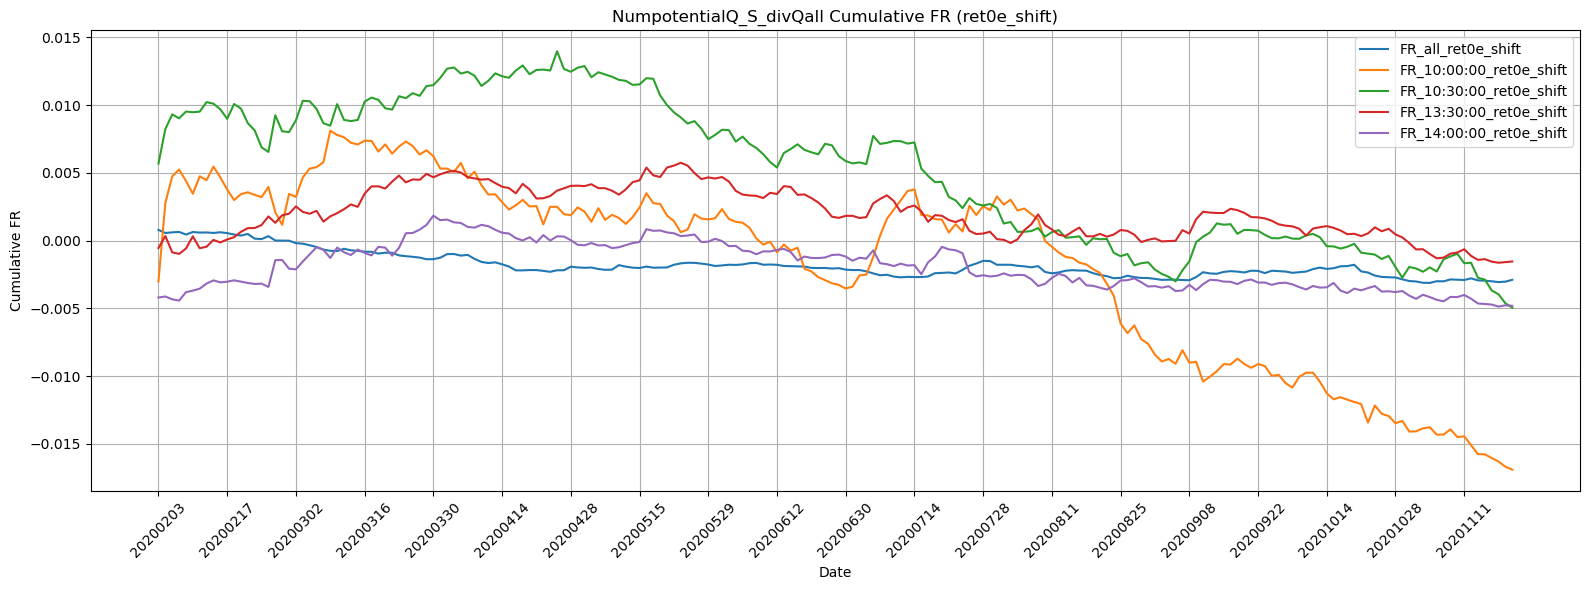

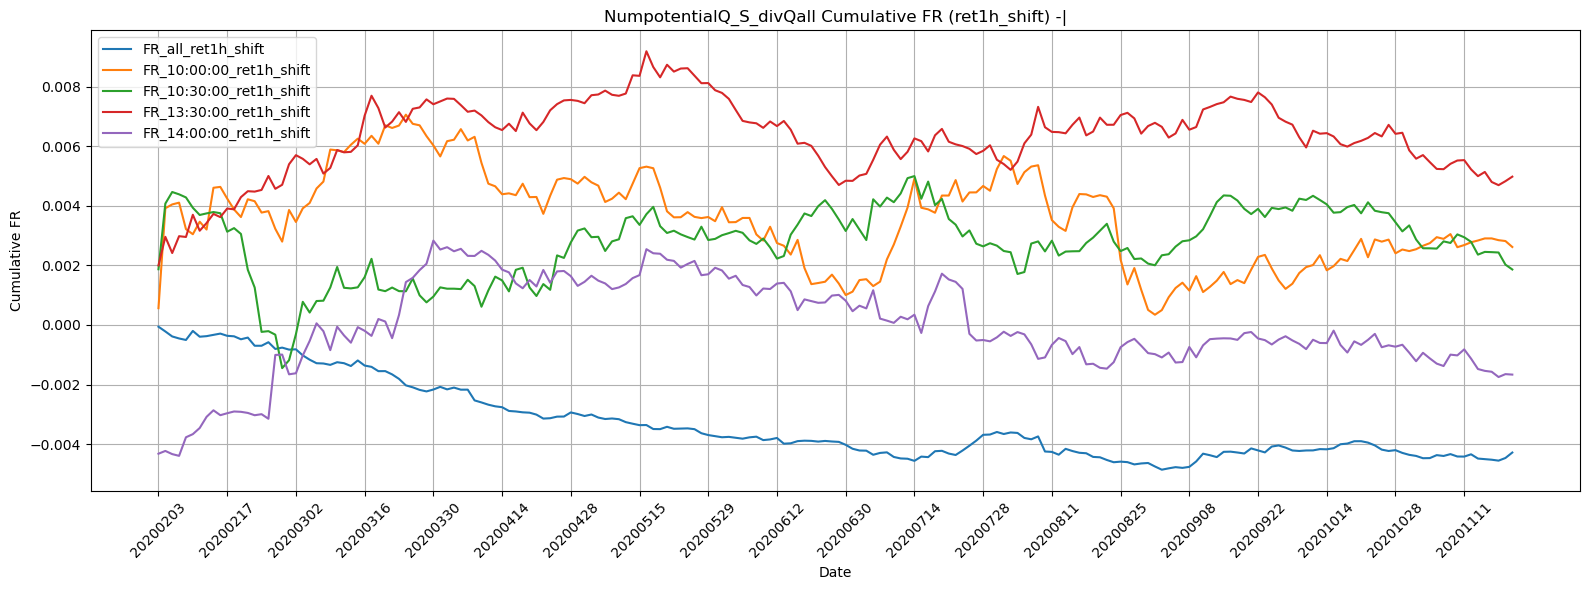

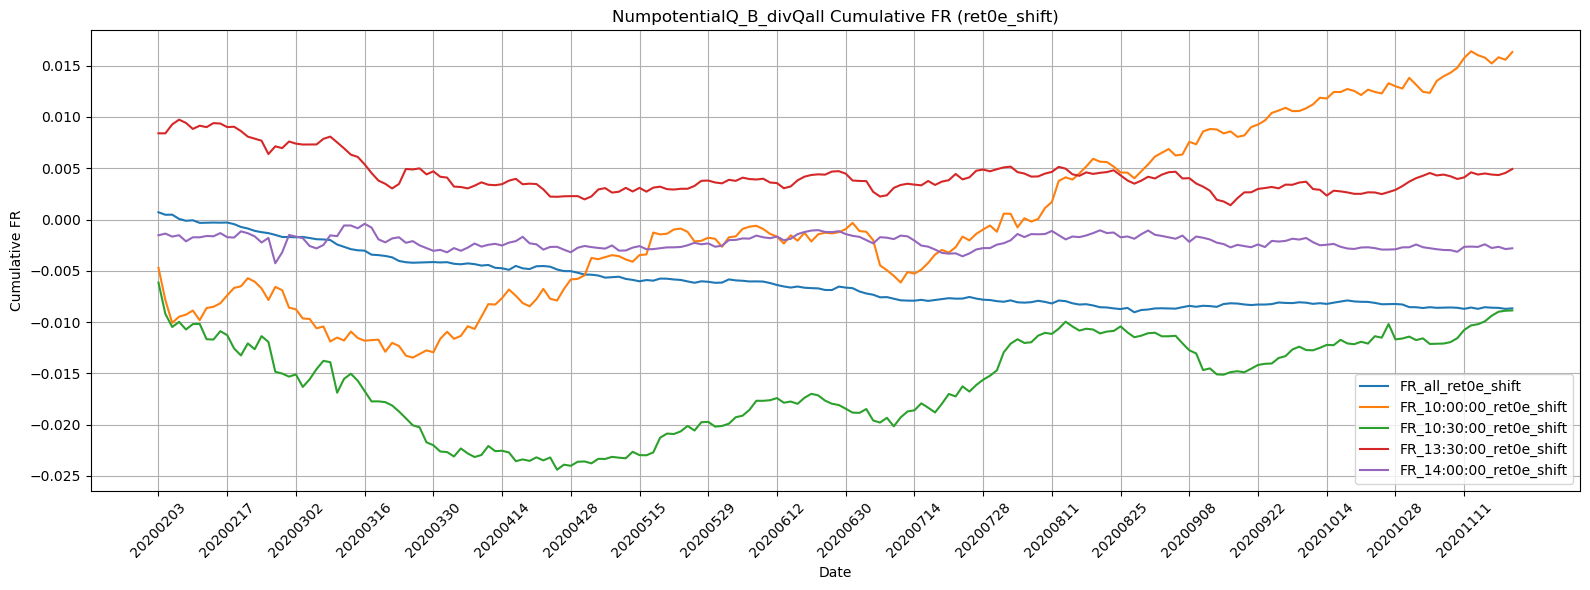

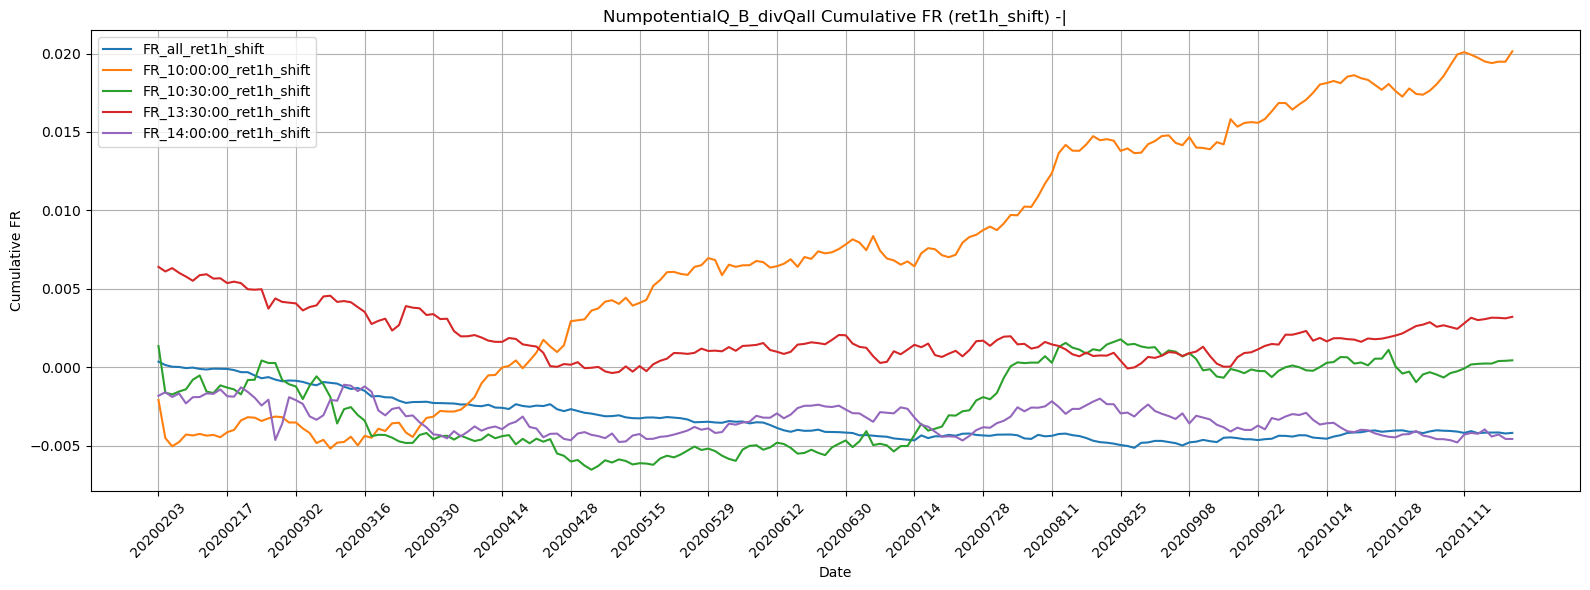

ValueError: Data must be 1-dimensional, got ndarray of shape (198, 2) instead

In [ ]:
# raise Exception('pls')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_cols(feat_col):
    # # 假设你已经有以下变量
    # feat_col = 'Around3s_AvgPrc_minusclose'
    ret_cols = ['ret0e_shift', 'ret1h_shift']
    time_points = ['10:00:00', '10:30:00', '13:30:00', '14:00:00']

    df = feature_all_df.reset_index()

    # ---------- 全部时间点 (FR_all_*) ----------
    fr_all_results = {}
    for ret_col in ret_cols:
        sub_df = df[[feat_col, ret_col, 'date']].dropna()

        # 按date groupby，计算 FR = cov(x, y) / std(x)
        grouped = sub_df.groupby('date')
        mean_x = grouped[feat_col].transform('mean')
        mean_y = grouped[ret_col].transform('mean')
        std_x = grouped[feat_col].transform('std')

        cov_xy = ((sub_df[feat_col] - mean_x) * (sub_df[ret_col] - mean_y)).groupby(sub_df['date']).mean()
        std_x_daily = std_x.groupby(sub_df['date']).first()  # std(x)是一样的，随便取一个就行

        fr = cov_xy / std_x_daily.replace(0, np.nan)
        fr_all_results[f'FR_all_{ret_col}'] = fr

    # ---------- 特定时间点 (FR_{time}_{ret_col}) ----------
    fr_time_results = {}

    for tp in time_points:
        df_tp = df[df['time'] == tp].dropna(subset=[feat_col] + ret_cols)
        for ret_col in ret_cols:
            grouped = df_tp.groupby('date')
            x = df_tp[feat_col]
            y = df_tp[ret_col]
            mean_x = grouped[feat_col].transform('mean')
            mean_y = grouped[ret_col].transform('mean')
            std_x = grouped[feat_col].transform('std')

            cov_xy = ((x - mean_x) * (y - mean_y)).groupby(df_tp['date']).mean()
            std_x_daily = std_x.groupby(df_tp['date']).first()

            fr = cov_xy / std_x_daily.replace(0, np.nan)
            fr_time_results[f'FR_{tp}_{ret_col}'] = fr

    # 合并所有结果
    fr_all_df = pd.DataFrame(fr_all_results)
    fr_time_df = pd.DataFrame(fr_time_results)
    fr_df = pd.concat([fr_all_df, fr_time_df], axis=1)

    # 计算 cumulative FR
    cumulative_fr_df = fr_df.cumsum()


    # 分别提取 ret0e 和 ret1h 的 FR 列
    fr_0e_cols = [col for col in cumulative_fr_df.columns if 'ret0e_shift' in col]
    fr_1h_cols = [col for col in cumulative_fr_df.columns if 'ret1h_shift' in col]

    # 画 ret0e_shift 的 Cumulative FR 图
    plt.figure(figsize=(16, 6))
    for col in fr_0e_cols:
        plt.plot(cumulative_fr_df.index, cumulative_fr_df[col], label=col)

    plt.title(f'{feat_col} Cumulative FR (ret0e_shift)')
    plt.xlabel('Date')
    plt.ylabel('Cumulative FR')
    plt.legend()
    plt.grid(True)
    plt.xticks(cumulative_fr_df.index[::10], rotation=45)
    plt.tight_layout()
    plt.show()

    # 画 ret1h_shift 的 Cumulative FR 图
    plt.figure(figsize=(16, 6))
    for col in fr_1h_cols:
        plt.plot(cumulative_fr_df.index, cumulative_fr_df[col], label=col)

    plt.title(f'{feat_col} Cumulative FR (ret1h_shift) -|')
    plt.xlabel('Date')
    plt.ylabel('Cumulative FR')
    plt.legend()
    plt.grid(True)
    plt.xticks(cumulative_fr_df.index[::10], rotation=45)
    plt.tight_layout()
    plt.show()
#     fr_df.to_parquet(f'/data/beef3/mike/pshared/GAlpha_custom_build/wensheng_jawN9J/fr_save/{feat_col}.parquet', engine="pyarrow", compression="snappy")
    
for feat_col in  [
    'Mean_filteractBuydelayl_addQ_divall',
    'Mean_filteractSelldelayl_addQ_divall',
    'Mean_filteractBuydelayl_addQ_divall_real',
    'Mean_filteractSelldelayl_addQ_divall_real',
    'Mean_filteractBuydelayl_addQ_divall_trd',
    'Mean_filteractSelldelayl_addQ_divall_trd',
    'Mean_filteractdelayl_addQ_BSdivall',
    'Mean_filteractdelayl_addQ_BSadddivall',
    'Mean_filteractdelayl_addQ_BSdivall_real',
    'Mean_filteractdelayl_addQ_BSadddivall_real',
    'Mean_filteractdelayl_addQ_BSdivall_trd',
    'Mean_filteractdelayl_addQ_BSadddivall_trd',
    'Mean_filteractdelayl_addQ_BSratio',
    'Std_filteractBuydelayl_addQ_divall',
    'Std_filteractSelldelayl_addQ_divall',
    'Std_filteractBuydelayl_addQ_divall_real',
    'Std_filteractSelldelayl_addQ_divall_real',
    'Std_filteractdelayl_addQ_BSdivall',
    'Std_filteractdelayl_addQ_BSratio',
    'Std_filteractdelayl_addQ_BSratiostd',
    'Std_filteractdelayl_addQ_BSadddivall',
    'Mean_filteractBuyRatiosl_addQ_divall',
    'Mean_filteractSellRatiosl_addQ_divall',
    'Mean_filteractRatiosl_addQ_BSdivall',
    'Mean_filteractRatiosl_addQ_BSratio',
    'Mean_filteractRatiosl_addQ_BSadddivall',
    'Std_filteractBuyRatiosl_addQ_divall',
    'Std_filteractSellRatiosl_addQ_divall',
    'Std_filteractRatiosl_addQ_BSdivall',
    'Std_filteractRatiosl_addQ_BSratio',
    'Std_filteractRatiosl_addQ_BSratiostd',
    'Std_filteractRatiosl_addQ_BSadddivall']:
    plot_cols(feat_col)